# 🛸 Drone Fleet Monitoring — Data Visualization & Insights

Notebook này đọc trực tiếp từ **`drone_fleet.db`** (đặt CÙNG THƯ MỤC với notebook —
giống layout VS Code của bạn: `app.py`, `schema.py`, `kalman_filter.py`,
`m1_streaming.py`, `m2_analytics_pipeline.py`, `m4_ml_engineer.py`, `drone_fleet.db`).

Mọi chart đều tính trực tiếp từ dữ liệu thật trong DB — không có số nào bị mock.
Tất cả hình được lưu vào thư mục **`fig/`** (tự tạo nếu chưa có), tên file đánh số
theo thứ tự trong notebook.

**Cấu trúc:**
1. Setup & load data
2. Data overview & pipeline health (volume, backlog, hardware failures)
3. Feature distributions (histogram + boxplot theo profile)
4. Correlation giữa các feature
5. Time-series: battery / wind / motor temp theo profile
6. GPS Kalman smoothing (bao gồm đo lường mức độ làm mượt)
7. Fleet health heatmap (drone × window, theo status M2 tính)
8. M4 — ETR quantile regression
9. Model diagnostic — phát hiện target bị leakage
10. So sánh target cũ (placeholder) vs target đã sửa (drain-rate)


## 1. Setup & load data

In [1]:
import os
import sqlite3
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

%matplotlib inline

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.linewidth"] = 0.8

# ----------------------------------------------------------------------------
# QUAN TRỌNG: DB_PATH là đường dẫn TƯƠNG ĐỐI — chạy notebook này từ đúng thư mục
# chứa drone_fleet.db (thư mục project của bạn) để không bị lỗi "unable to open
# database file". Không hardcode đường dẫn tuyệt đối của máy khác.
# ----------------------------------------------------------------------------
DB_PATH = "drone_fleet.db"
FIG_DIR = "fig"
os.makedirs(FIG_DIR, exist_ok=True)

assert os.path.exists(DB_PATH), (
    f"Không tìm thấy {DB_PATH} trong thư mục hiện tại ({os.getcwd()}). "
    f"Đặt notebook này CÙNG THƯ MỤC với drone_fleet.db rồi chạy lại."
)

# Palette (đồng bộ với bản PowerPoint đã gửi trước đó)
NAVY, DEEPBLUE, TEAL, MINT = "#21295C", "#065A82", "#1C7293", "#02C39A"
CORAL, GOLD, GREY = "#F96167", "#F9E795", "#8A94A6"
STATUS_COLORS = {"green": "#2C9F5E", "yellow": "#E8B93B", "red": "#D64545"}

def style_ax(ax):
    ax.set_facecolor("white")
    ax.grid(alpha=0.25, linewidth=0.6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, facecolor="white", bbox_inches="tight", dpi=200)
    print("Saved ->", path)


In [2]:
conn = sqlite3.connect(DB_PATH)

dim_drones = pd.read_sql_query("SELECT * FROM dim_drones", conn)
telemetry = pd.read_sql_query("SELECT * FROM fact_telemetry", conn)
telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"], utc=True)

gold = pd.read_sql_query("SELECT * FROM fact_gold_summary", conn)
gold["window_end"] = pd.to_datetime(gold["window_end"], utc=True)

n_bronze = pd.read_sql_query("SELECT COUNT(*) c FROM bronze_telemetry", conn).iloc[0, 0]
try:
    pipeline_state = pd.read_sql_query("SELECT * FROM m2_pipeline_state", conn)
    last_processed_log_id = int(pipeline_state["last_bronze_log_id"].iloc[0])
except Exception:
    last_processed_log_id = None

profile_map = dim_drones.set_index("drone_id")["profile_label"].to_dict()
telemetry["profile_label"] = telemetry["drone_id"].map(profile_map)
gold["profile_label"] = gold["drone_id"].map(profile_map)

PROFILE_COLORS = {
    "baseline": GREY, "heavy_payload": TEAL, "storm_zone": DEEPBLUE,
    "heavy_in_storm": NAVY, "aging_battery": CORAL, "cold_weather": "#5AA9E6",
    "poor_gps_rural": MINT, "worst_case": "#B3001B",
}

t0 = telemetry["timestamp"].min()
telemetry["minutes"] = (telemetry["timestamp"] - t0).dt.total_seconds() / 60.0

print("dim_drones       :", dim_drones.shape)
print("fact_telemetry    :", telemetry.shape)
print("fact_gold_summary :", gold.shape)
print("bronze_telemetry  :", n_bronze, "rows total (raw, before Silver cleaning)")
print("M2 last processed log_id:", last_processed_log_id)
dim_drones[["drone_id", "profile_label", "payload_kg", "wind_zone",
            "battery_health", "ambient_temp_c", "gps_quality", "network_zone"]]


dim_drones       : (5000, 11)
fact_telemetry    : (973508, 17)
fact_gold_summary : (5000, 21)
bronze_telemetry  : 973533 rows total (raw, before Silver cleaning)
M2 last processed log_id: 973508


,drone_id,profile_label,payload_kg,wind_zone,battery_health,ambient_temp_c,gps_quality,network_zone
0,DRONE_00001,baseline,0.0,moderate,1.00,25.0,1.0,suburban
1,DRONE_00002,heavy_payload,4.0,moderate,1.00,25.0,1.0,suburban
2,DRONE_00003,storm_zone,0.0,storm,1.00,25.0,1.0,suburban
3,DRONE_00004,heavy_in_storm,4.0,storm,1.00,25.0,1.0,suburban
4,DRONE_00005,aging_battery,0.0,moderate,0.75,25.0,1.0,suburban
...,...,...,...,...,...,...,...,...
4995,DRONE_04996,heavy_in_storm,4.0,storm,1.00,25.0,1.0,suburban
4996,DRONE_04997,aging_battery,0.0,moderate,0.75,25.0,1.0,suburban
4997,DRONE_04998,cold_weather,0.0,moderate,1.00,5.0,1.0,suburban
4998,DRONE_04999,poor_gps_rural,0.0,moderate,1.00,25.0,0.6,rural


## 2. Data overview & pipeline health

Trước khi vẽ insight, kiểm tra **chính pipeline có đang chạy đúng không**:
- Bronze → Silver có bị tồn đọng (backlog) không?
- Có drone nào phần cứng lỗi (`hardware_ok=False`) nhiều bất thường không?


Saved -> fig\01_pipeline_volume_and_backlog.png


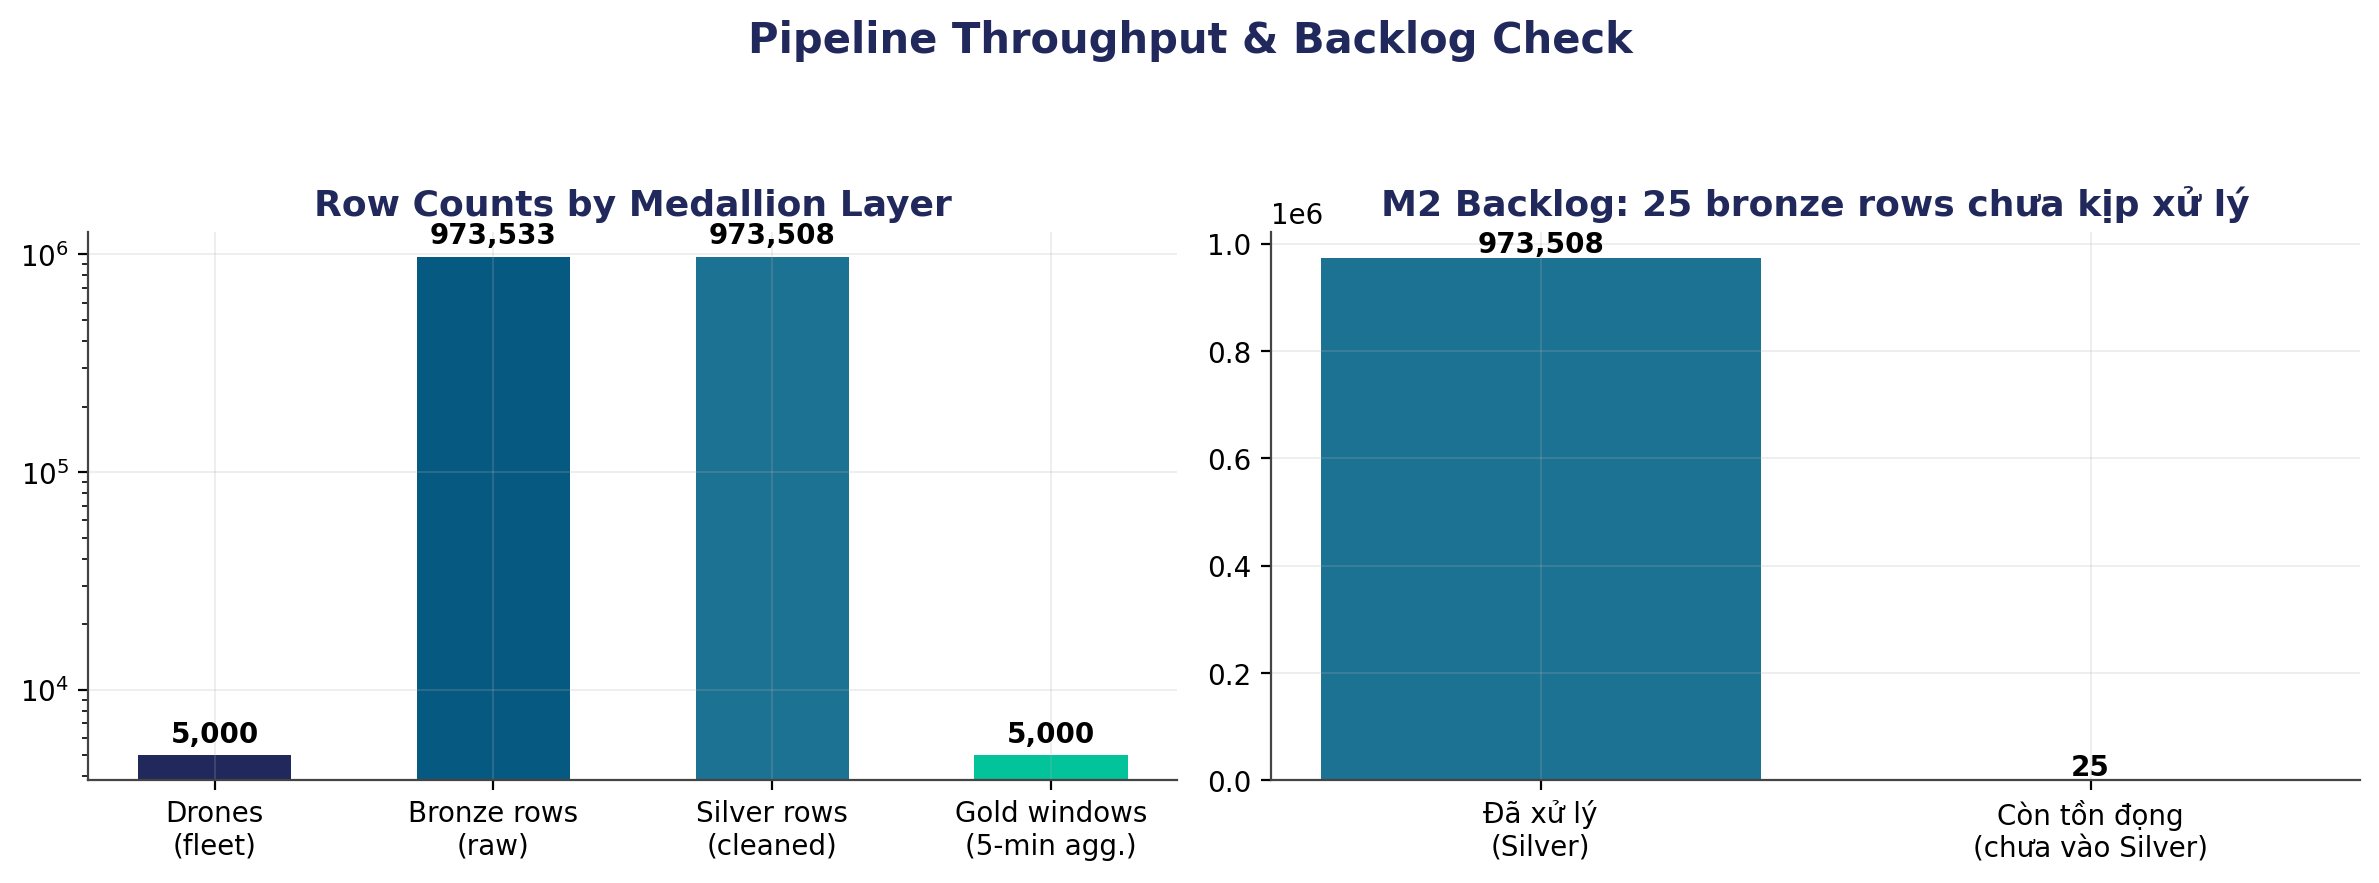

In [3]:
backlog = n_bronze - (last_processed_log_id or telemetry.shape[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=200)

# --- (a) Row counts theo layer ---
labels = ["Drones\n(fleet)", "Bronze rows\n(raw)", "Silver rows\n(cleaned)", "Gold windows\n(5-min agg.)"]
values = [dim_drones.shape[0], n_bronze, telemetry.shape[0], gold.shape[0]]
bars = axes[0].bar(labels, values, color=[NAVY, DEEPBLUE, TEAL, MINT], width=0.55)
axes[0].set_yscale("log")
for b, v in zip(bars, values):
    axes[0].text(b.get_x() + b.get_width()/2, v * 1.15, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Row Counts by Medallion Layer", fontsize=13, fontweight="bold", color=NAVY)
style_ax(axes[0])

# --- (b) Backlog Bronze -> Silver (KHÔNG phải "dữ liệu bị từ chối" — chỉ là
# M2 chưa kịp xử lý hết nếu pipeline vẫn đang chạy) ---
axes[1].bar(["Đã xử lý\n(Silver)", "Còn tồn đọng\n(chưa vào Silver)"],
            [telemetry.shape[0], max(backlog, 0)],
            color=[TEAL, GOLD])
axes[1].set_title(f"M2 Backlog: {max(backlog,0)} bronze rows chưa kịp xử lý", fontsize=13, fontweight="bold", color=NAVY)
style_ax(axes[1])
for i, v in enumerate([telemetry.shape[0], max(backlog, 0)]):
    axes[1].text(i, v + max(values)*0.01, f"{v:,}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Pipeline Throughput & Backlog Check", fontsize=15, fontweight="bold", color=NAVY, y=1.04)
fig.tight_layout()
savefig(fig, "01_pipeline_volume_and_backlog.png")
plt.show()


Saved -> fig\02_hardware_failures_by_drone.png


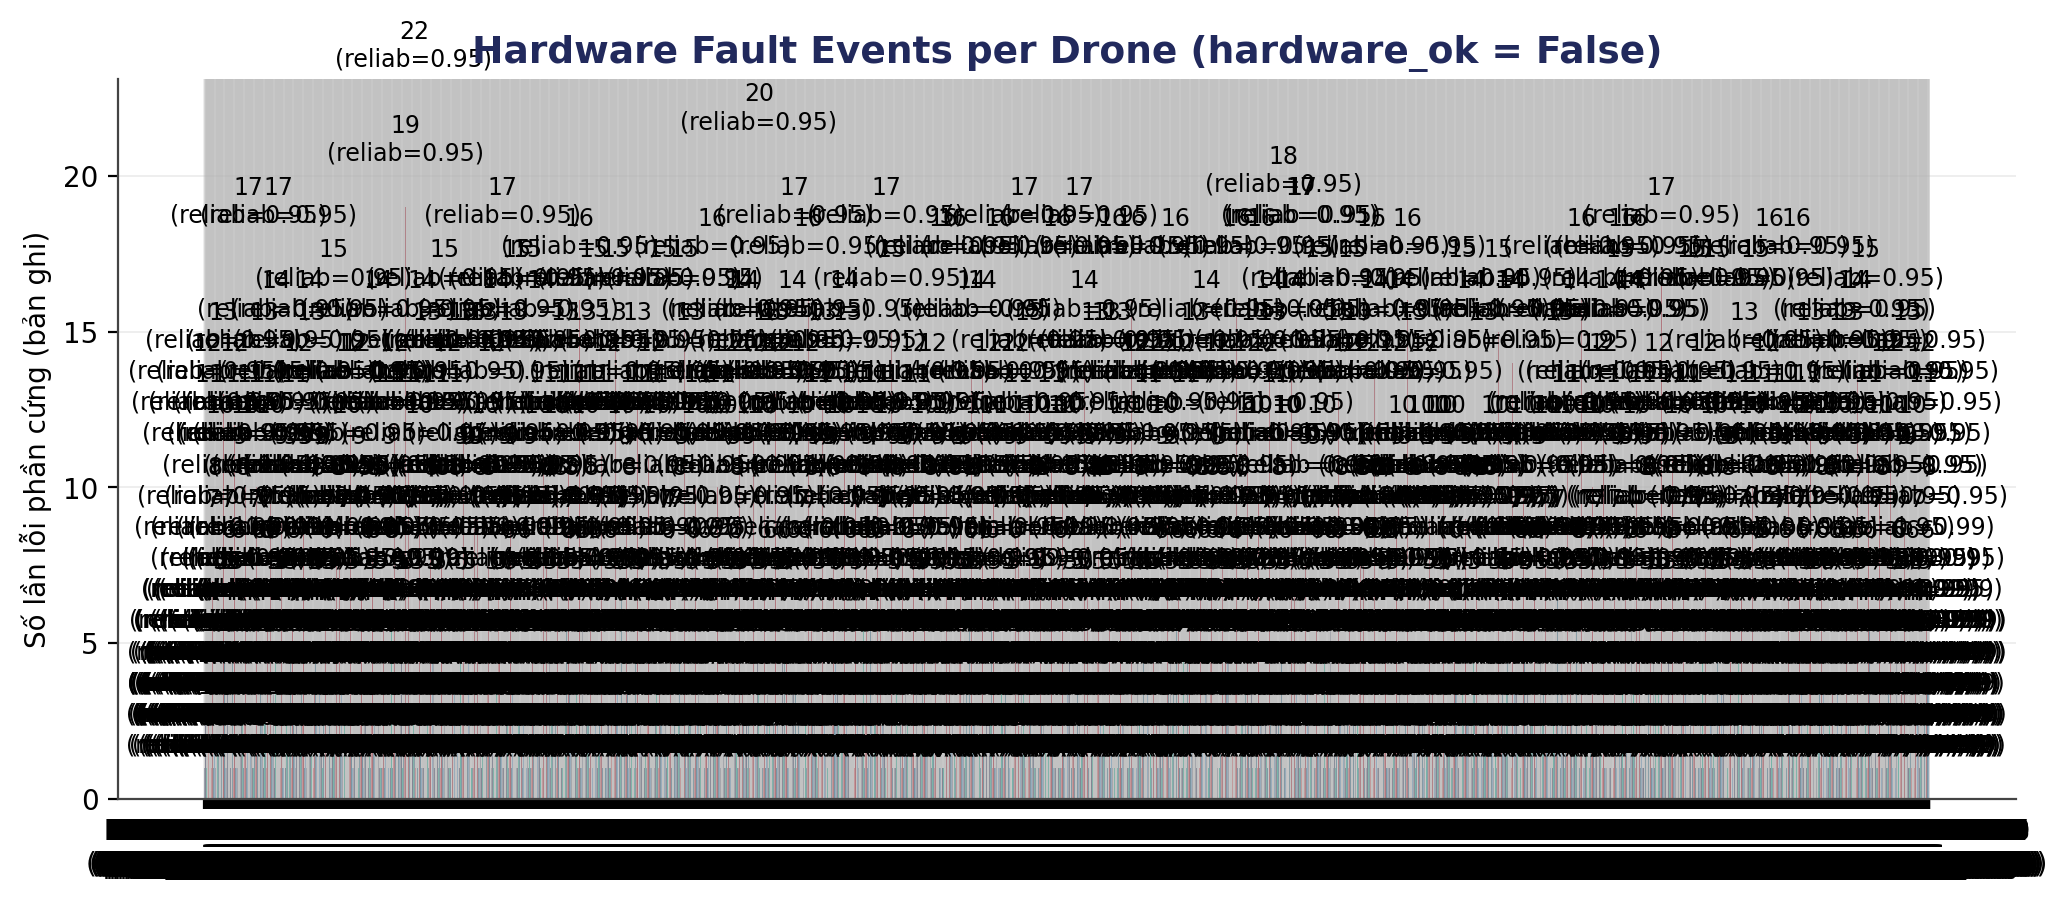

drone_id
DRONE_00001    1
DRONE_00002    0
DRONE_00003    2
DRONE_00004    3
DRONE_00005    2
              ..
DRONE_04996    0
DRONE_04997    1
DRONE_04998    4
DRONE_04999    3
DRONE_05000    8
Name: hardware_ok, Length: 5000, dtype: int64


In [4]:
# Hardware failure count theo drone -- kiểm tra hardware_reliability trong profile
# có thực sự tạo ra khác biệt quan sát được không (M3's stochastic model).
fail_counts = telemetry.groupby("drone_id")["hardware_ok"].apply(lambda s: (~s.astype(bool)).sum())
fail_counts = fail_counts.reindex(sorted(fail_counts.index))
labels_fc = [f"{d}\n({profile_map[d]})" for d in fail_counts.index]
reliab = dim_drones.set_index("drone_id")["hardware_reliability"].reindex(fail_counts.index)

fig, ax = plt.subplots(figsize=(10.5, 4.6), dpi=200)
colors_fc = [PROFILE_COLORS.get(profile_map[d], GREY) for d in fail_counts.index]
bars = ax.bar(labels_fc, fail_counts.values, color=colors_fc)
for b, v, r in zip(bars, fail_counts.values, reliab.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v}\n(reliab={r})", ha="center", fontsize=8.5)
ax.set_title("Hardware Fault Events per Drone (hardware_ok = False)", fontsize=13.5, fontweight="bold", color=NAVY)
ax.set_ylabel("Số lần lỗi phần cứng (bản ghi)")
style_ax(ax)
fig.tight_layout()
savefig(fig, "02_hardware_failures_by_drone.png")
plt.show()

print(fail_counts)


## 3. Phân phối các feature telemetry

Nhìn tổng thể phân phối (không tách theo thời gian) để phát hiện outlier /
hành vi bất thường của simulator, và so sánh giữa các profile.


Saved -> fig\03_feature_histograms.png


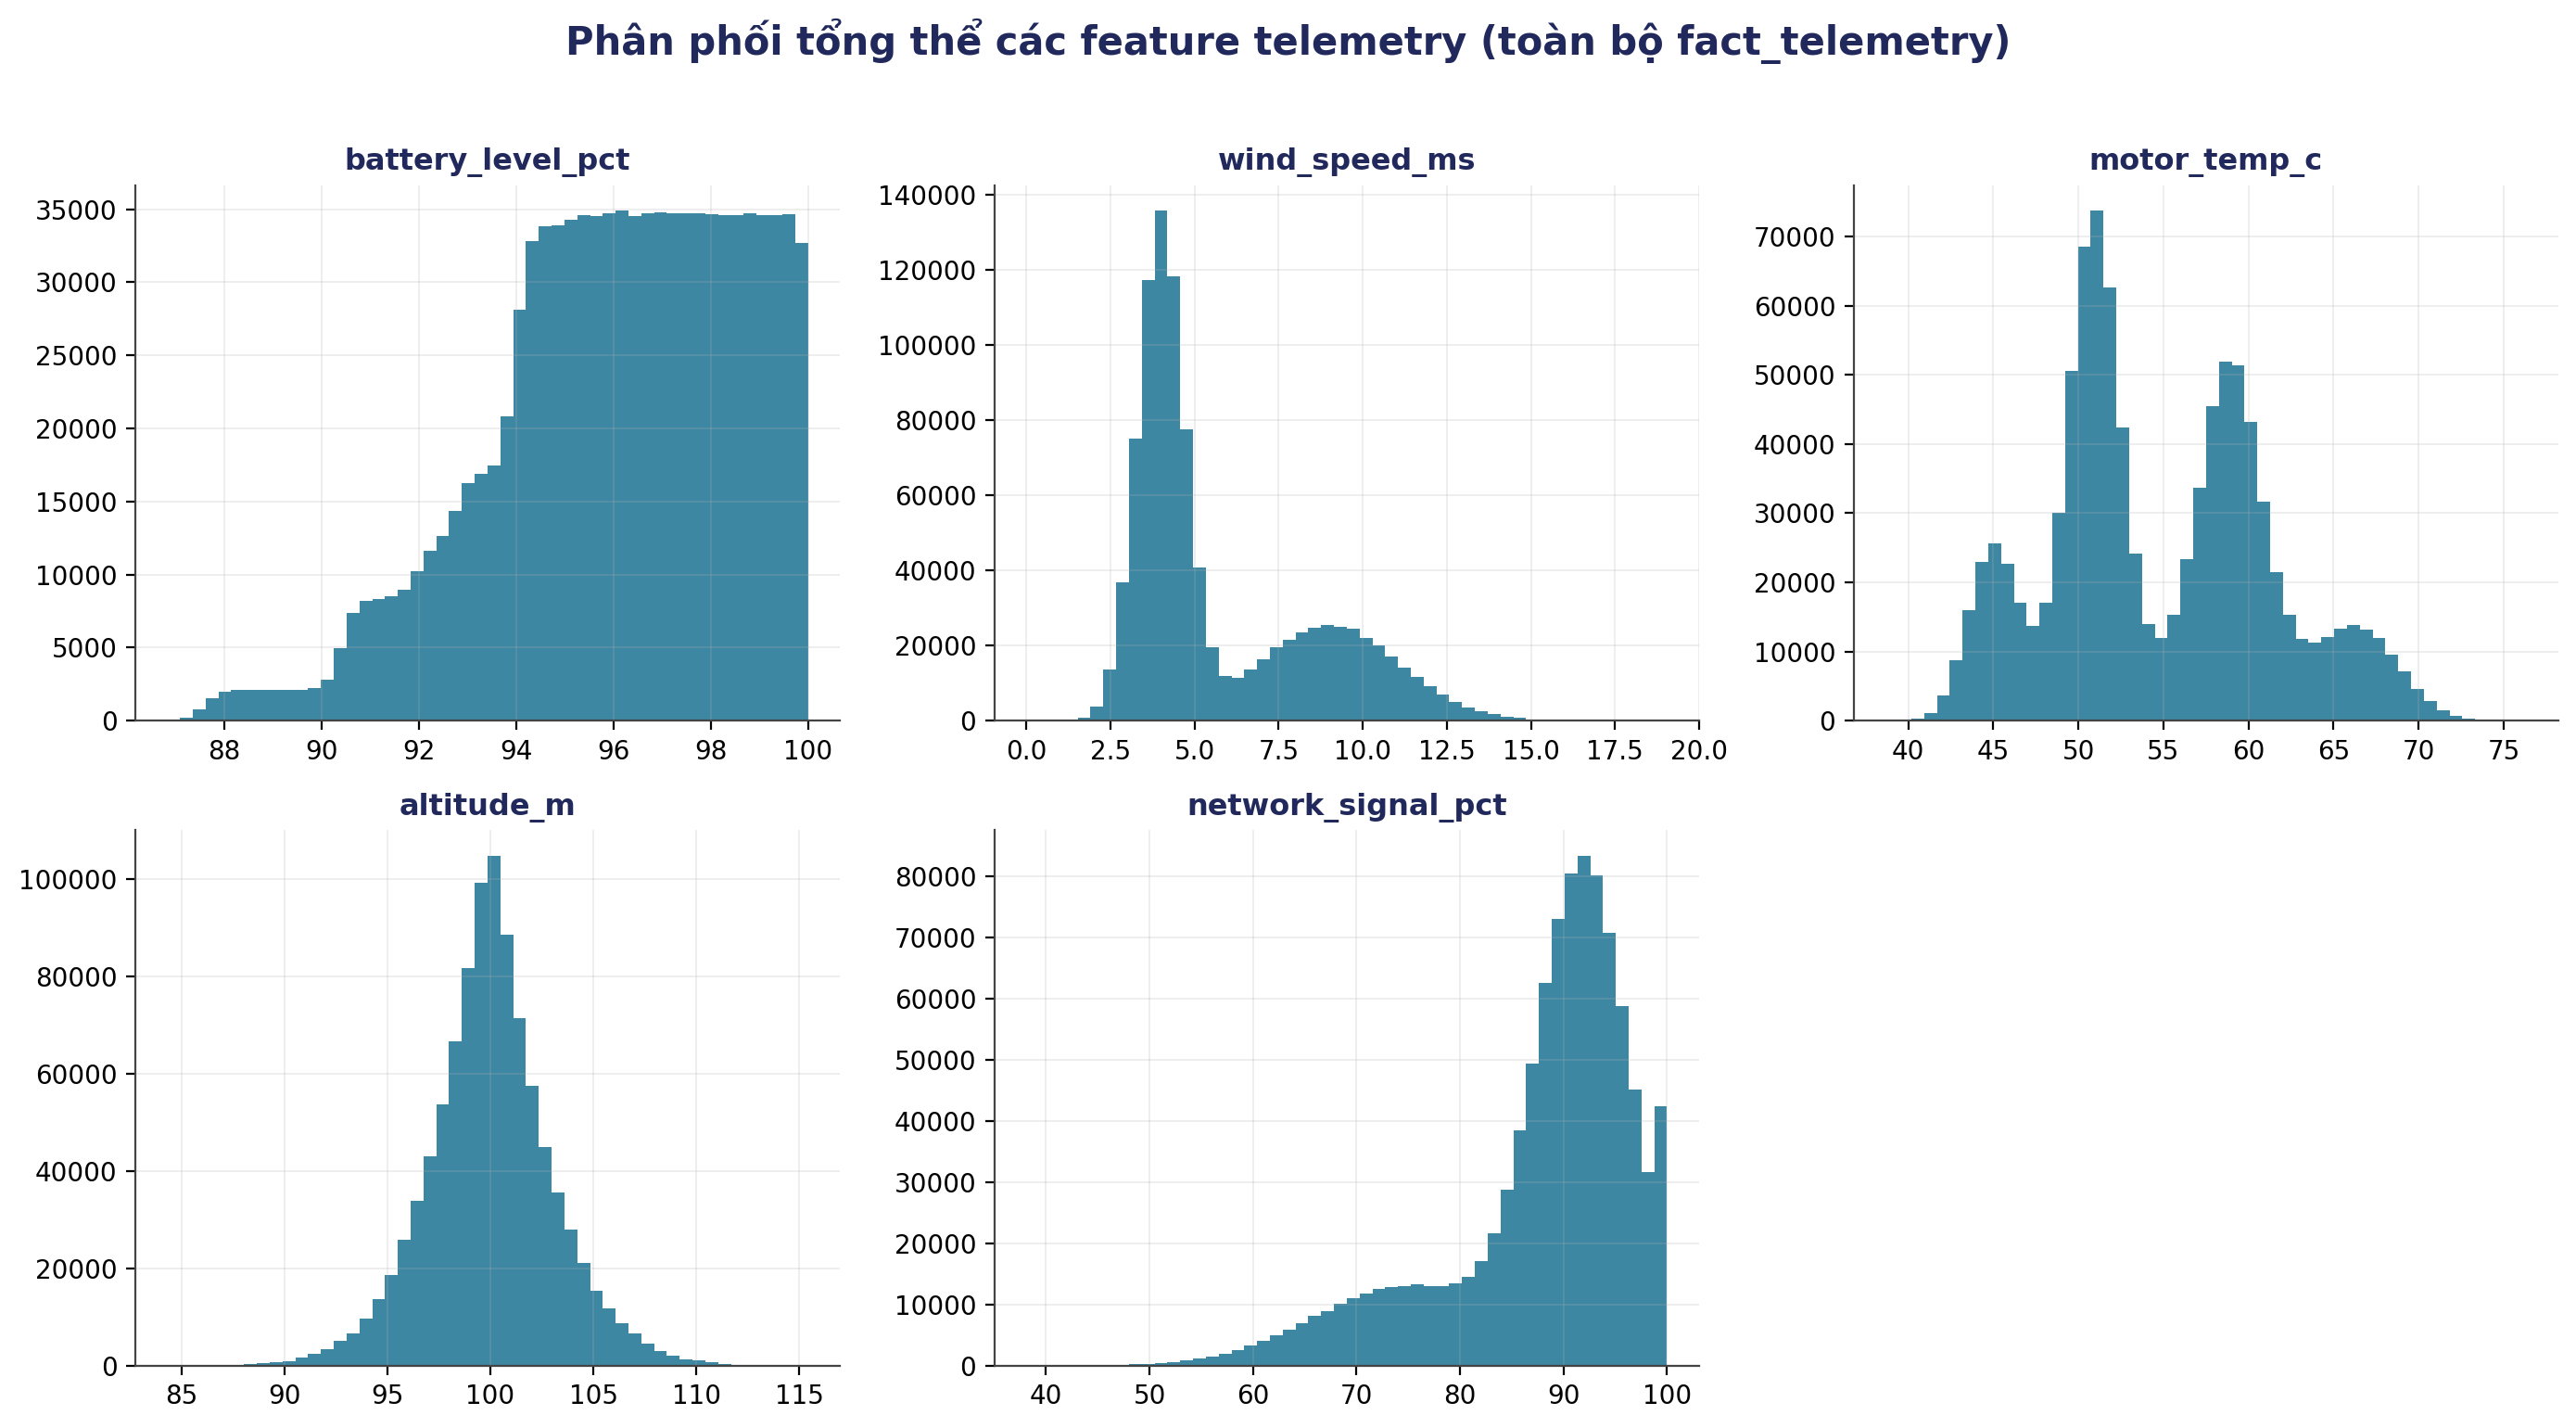

In [5]:
FEATURE_COLS = ["battery_level_pct", "wind_speed_ms", "motor_temp_c", "altitude_m", "network_signal_pct"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), dpi=200)
axes = axes.flatten()
for ax, col in zip(axes, FEATURE_COLS):
    ax.hist(telemetry[col], bins=50, color=TEAL, alpha=0.85)
    ax.set_title(col, fontsize=11.5, fontweight="bold", color=NAVY)
    style_ax(ax)
axes[-1].axis("off")
fig.suptitle("Phân phối tổng thể các feature telemetry (toàn bộ fact_telemetry)",
             fontsize=15, fontweight="bold", color=NAVY, y=1.02)
fig.tight_layout()
savefig(fig, "03_feature_histograms.png")
plt.show()


C:\Users\thien\AppData\Local\Temp\ipykernel_35496\2259210858.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_profile, labels=order, patch_artist=True, showfliers=False, widths=0.6)
C:\Users\thien\AppData\Local\Temp\ipykernel_35496\2259210858.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_profile, labels=order, patch_artist=True, showfliers=False, widths=0.6)
C:\Users\thien\AppData\Local\Temp\ipykernel_35496\2259210858.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_profile, labels=order, patch_artist=True, showfliers=False, widths=0.6

Saved -> fig\04_feature_boxplots_by_profile.png


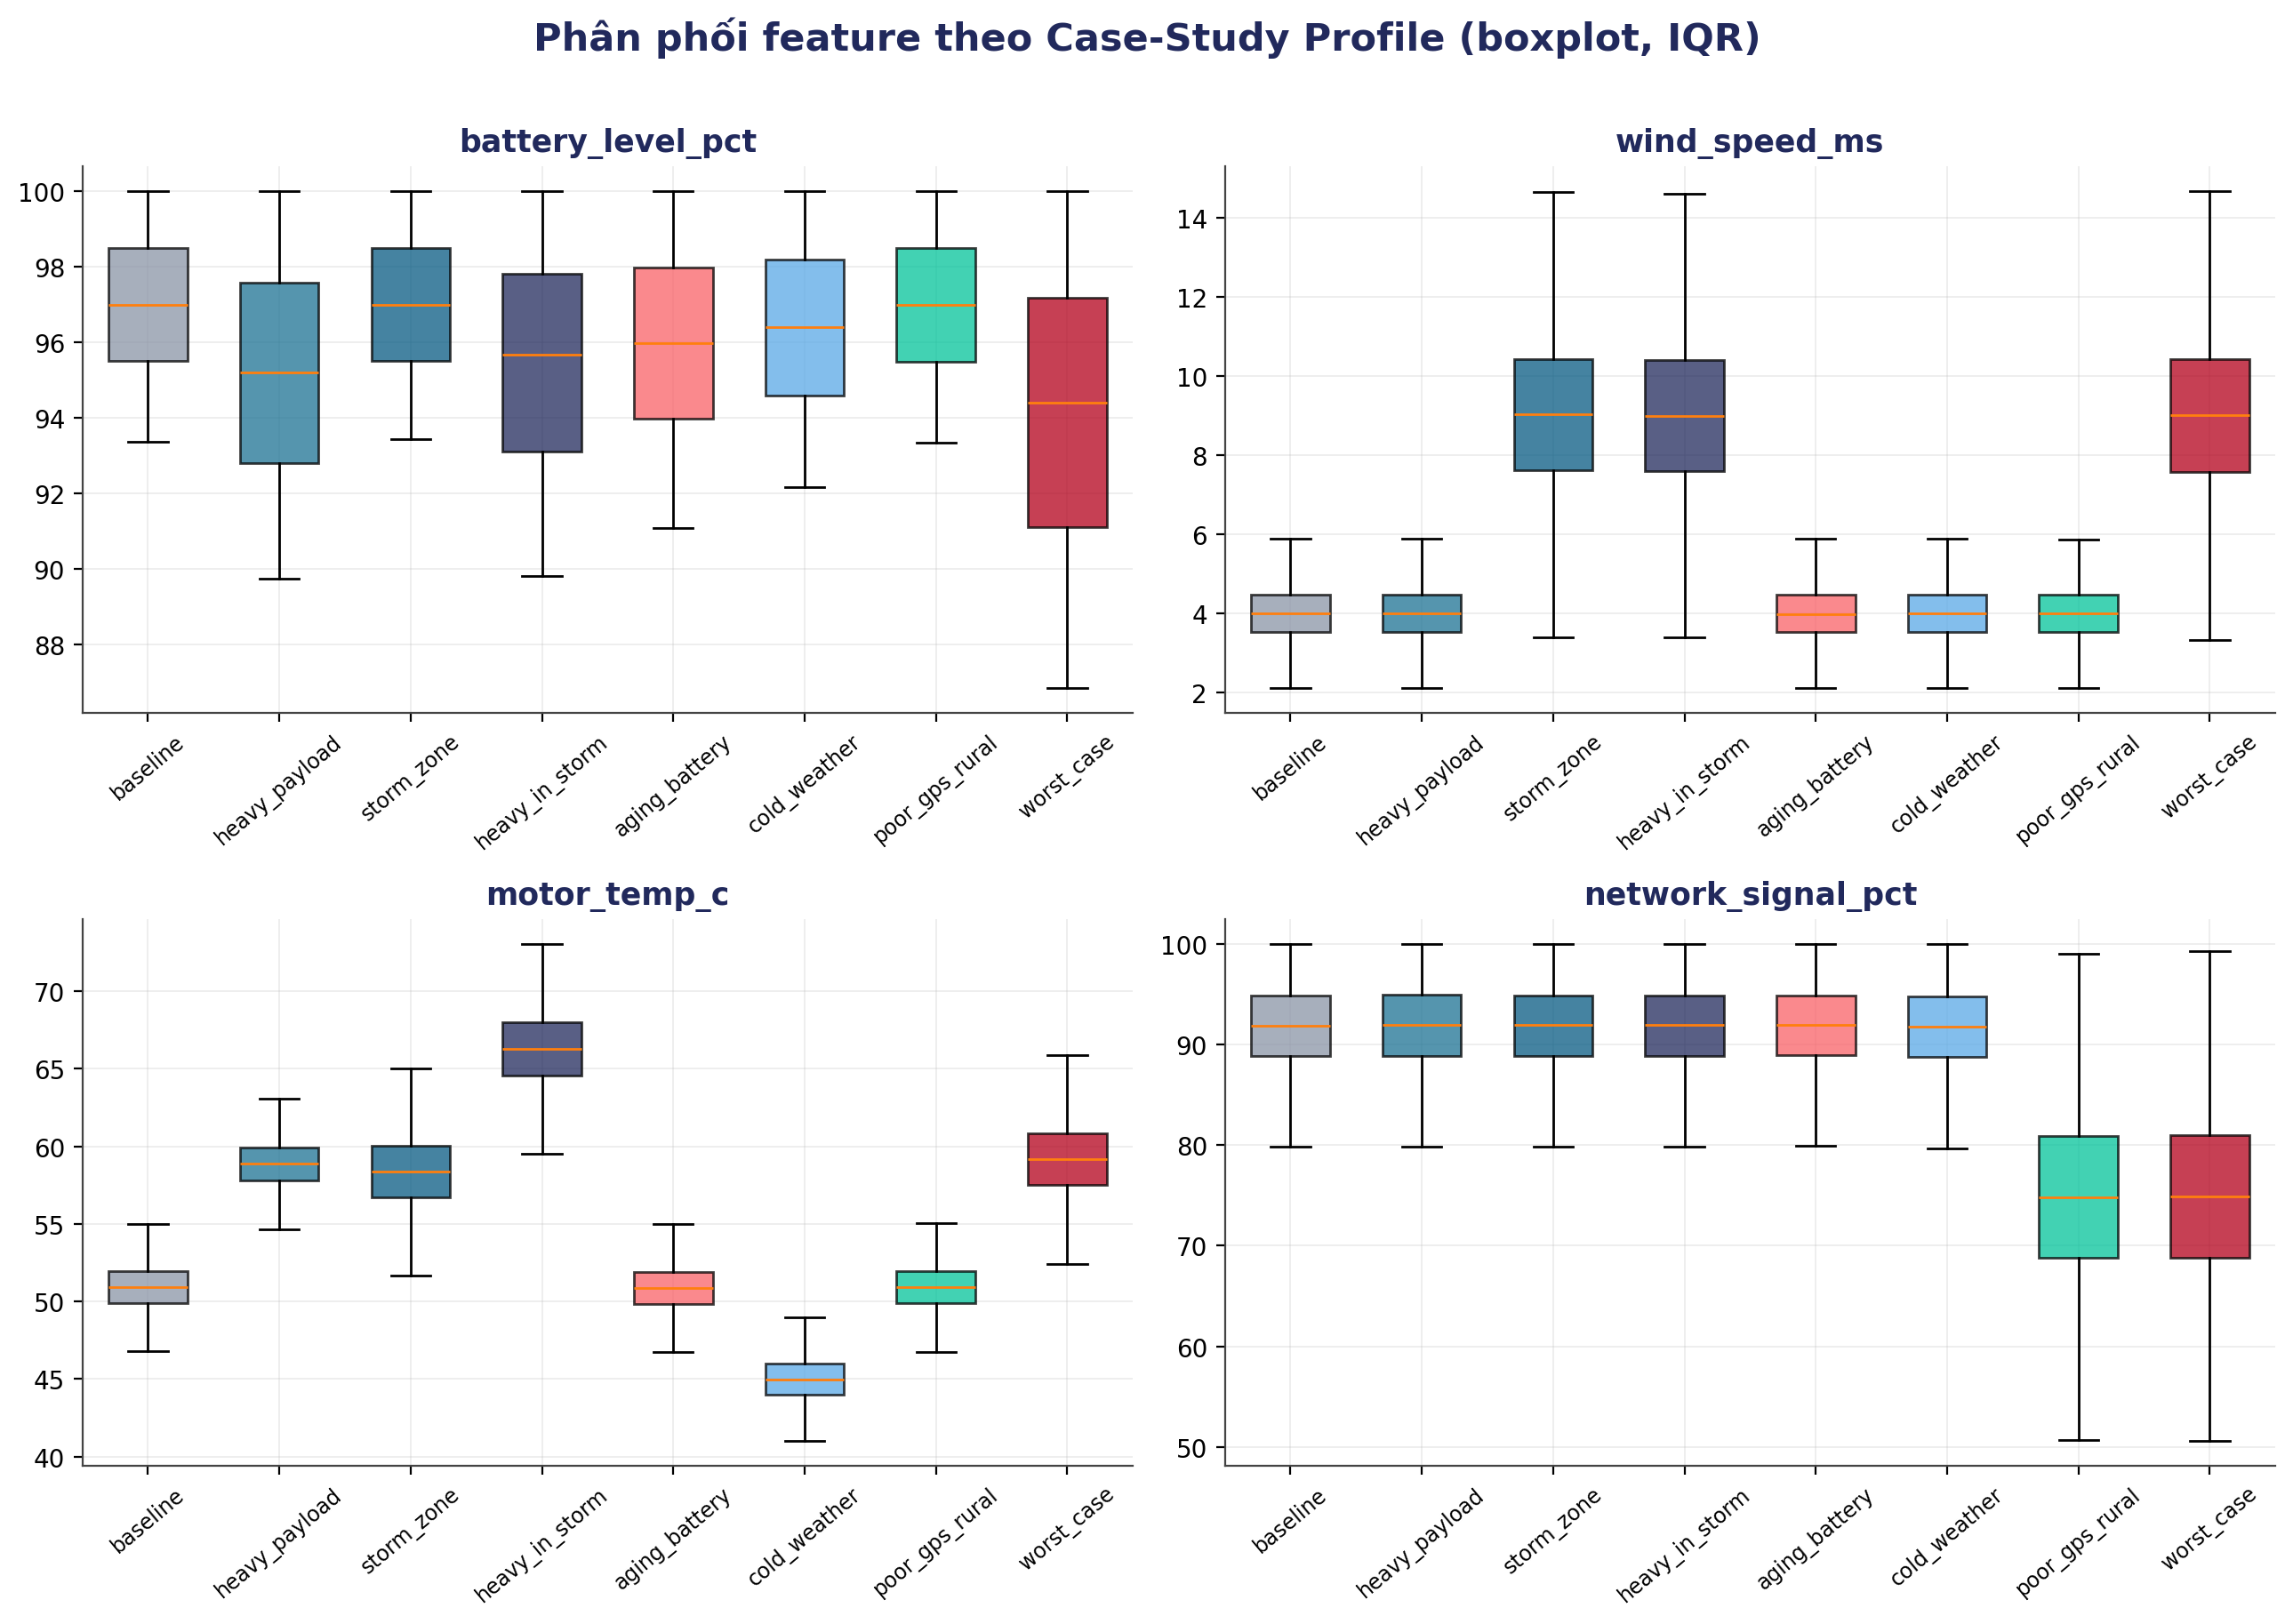

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=200)
box_cols = ["battery_level_pct", "wind_speed_ms", "motor_temp_c", "network_signal_pct"]
order = list(profile_map.values())
order = sorted(set(order), key=lambda p: list(PROFILE_COLORS).index(p) if p in PROFILE_COLORS else 99)

for ax, col in zip(axes.flatten(), box_cols):
    data_by_profile = [telemetry.loc[telemetry["profile_label"] == p, col] for p in order]
    bp = ax.boxplot(data_by_profile, labels=order, patch_artist=True, showfliers=False, widths=0.6)
    for patch, p in zip(bp["boxes"], order):
        patch.set_facecolor(PROFILE_COLORS.get(p, GREY))
        patch.set_alpha(0.75)
    ax.set_title(col, fontsize=12.5, fontweight="bold", color=NAVY)
    ax.tick_params(axis="x", rotation=40, labelsize=8.5)
    style_ax(ax)

fig.suptitle("Phân phối feature theo Case-Study Profile (boxplot, IQR)",
             fontsize=15.5, fontweight="bold", color=NAVY, y=1.01)
fig.tight_layout()
savefig(fig, "04_feature_boxplots_by_profile.png")
plt.show()


## 4. Ma trận tương quan giữa các feature (bao gồm target ETR hiện tại)

Saved -> fig\05_correlation_heatmap.png


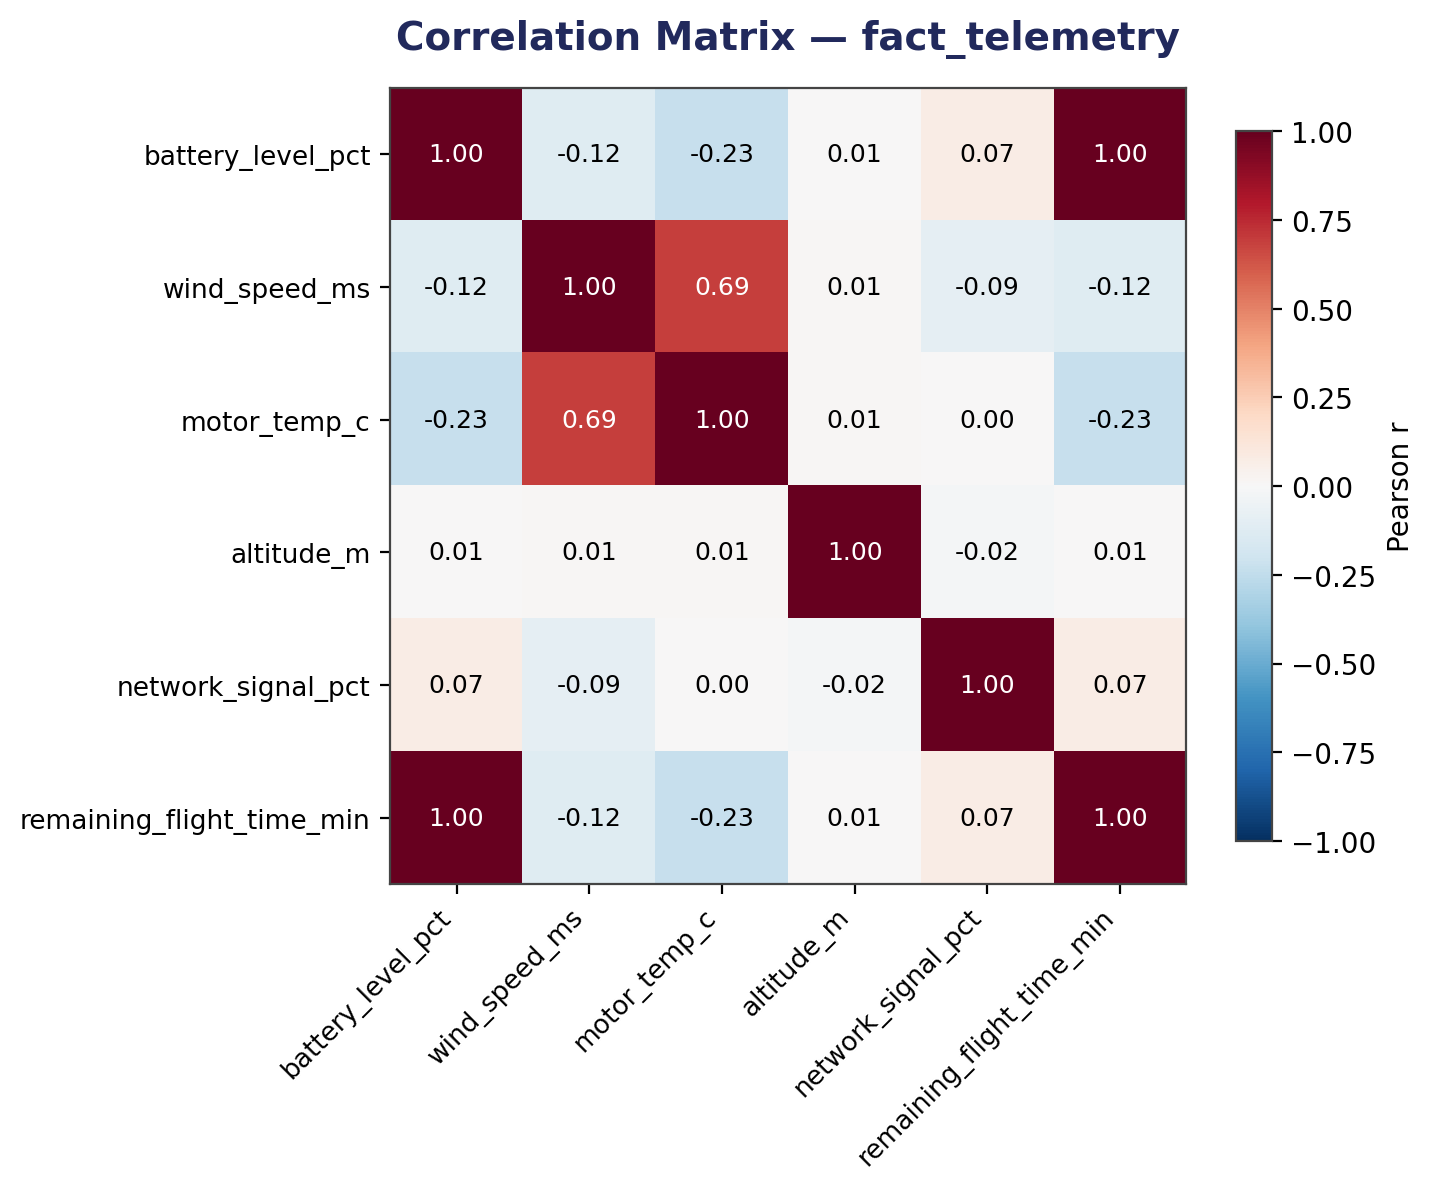

battery_level_pct            1.000000
remaining_flight_time_min    1.000000
network_signal_pct           0.072036
altitude_m                   0.005940
wind_speed_ms               -0.117440
motor_temp_c                -0.231476
Name: remaining_flight_time_min, dtype: float64


In [7]:
corr_cols = FEATURE_COLS + ["remaining_flight_time_min"]
corr = telemetry[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.2, 6.2), dpi=200)
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9.5)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=9.5)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=9, color="white" if abs(v) > 0.6 else "black")
ax.set_title("Correlation Matrix — fact_telemetry", fontsize=14, fontweight="bold", color=NAVY, pad=14)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
fig.tight_layout()
savefig(fig, "05_correlation_heatmap.png")
plt.show()

print(corr["remaining_flight_time_min"].sort_values(ascending=False))


## 5. Time-series theo Case-Study Profile

So sánh 8 drone (8 điều kiện bay khác nhau) theo thời gian mô phỏng.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6), dpi=200)
for pid, grp in telemetry.groupby("drone_id"):
    label = profile_map[pid]
    ax.plot(grp["minutes"], grp["battery_level_pct"], label=label,
            color=PROFILE_COLORS.get(label, GREY),
            linewidth=2.2 if label == "worst_case" else 1.6, alpha=0.95)
ax.set_xlabel("Simulated flight time (minutes)")
ax.set_ylabel("Battery level (%)")
ax.set_title("Battery Drain by Drone Case-Study Profile", fontsize=15, fontweight="bold", color=NAVY, pad=14)
ax.axhline(40, color=STATUS_COLORS["yellow"], linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(20, color=STATUS_COLORS["red"], linestyle="--", linewidth=1, alpha=0.6)
style_ax(ax)
ax.legend(loc="upper right", fontsize=9, frameon=False, ncol=2)
fig.tight_layout()
savefig(fig, "06_battery_drain_profiles.png")
plt.show()


C:\Users\thien\AppData\Local\Temp\ipykernel_35496\3594017123.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved -> fig\06_battery_drain_profiles.png


Saved -> fig\07_wind_motor_temp.png


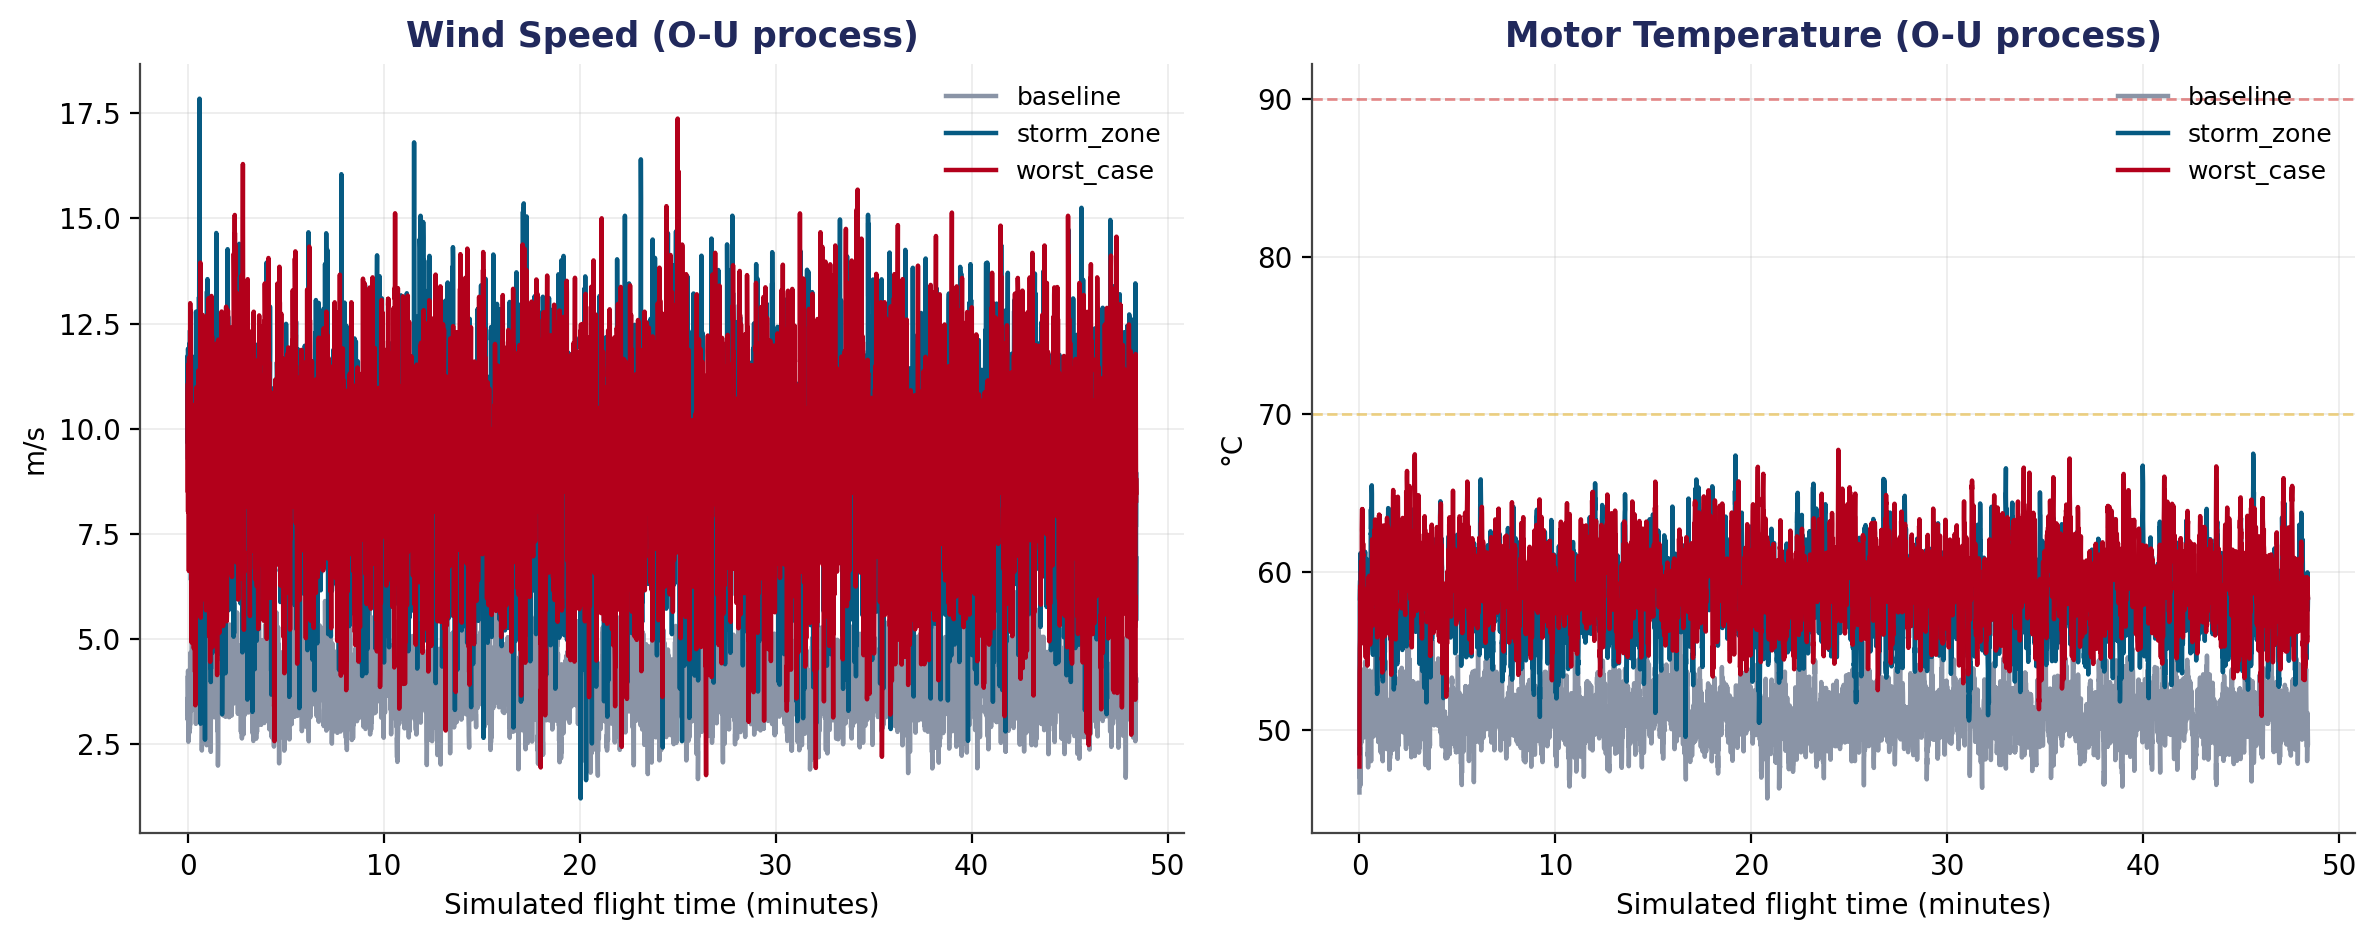

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=200)
sel = ["baseline", "storm_zone", "worst_case"]
for label in sel:
    pid = [k for k, v in profile_map.items() if v == label][0]
    grp = telemetry[telemetry["drone_id"] == pid]
    axes[0].plot(grp["minutes"], grp["wind_speed_ms"], label=label, color=PROFILE_COLORS[label], linewidth=1.6)
    axes[1].plot(grp["minutes"], grp["motor_temp_c"], label=label, color=PROFILE_COLORS[label], linewidth=1.6)
axes[0].set_title("Wind Speed (O-U process)", fontsize=12.5, fontweight="bold", color=NAVY); axes[0].set_ylabel("m/s")
axes[1].set_title("Motor Temperature (O-U process)", fontsize=12.5, fontweight="bold", color=NAVY); axes[1].set_ylabel("°C")
axes[1].axhline(70, color=STATUS_COLORS["yellow"], linestyle="--", linewidth=1, alpha=0.6)
axes[1].axhline(90, color=STATUS_COLORS["red"], linestyle="--", linewidth=1, alpha=0.6)
for ax in axes:
    ax.set_xlabel("Simulated flight time (minutes)"); style_ax(ax); ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
savefig(fig, "07_wind_motor_temp.png")
plt.show()


## 6. GPS Kalman Smoothing (import trực tiếp `kalman_filter.KalmanFilter2D` — M3)

Không viết lại thuật toán khác: gọi đúng class thật trong file `kalman_filter.py`
nằm cùng thư mục.


Saved -> fig\08_gps_kalman_path.png


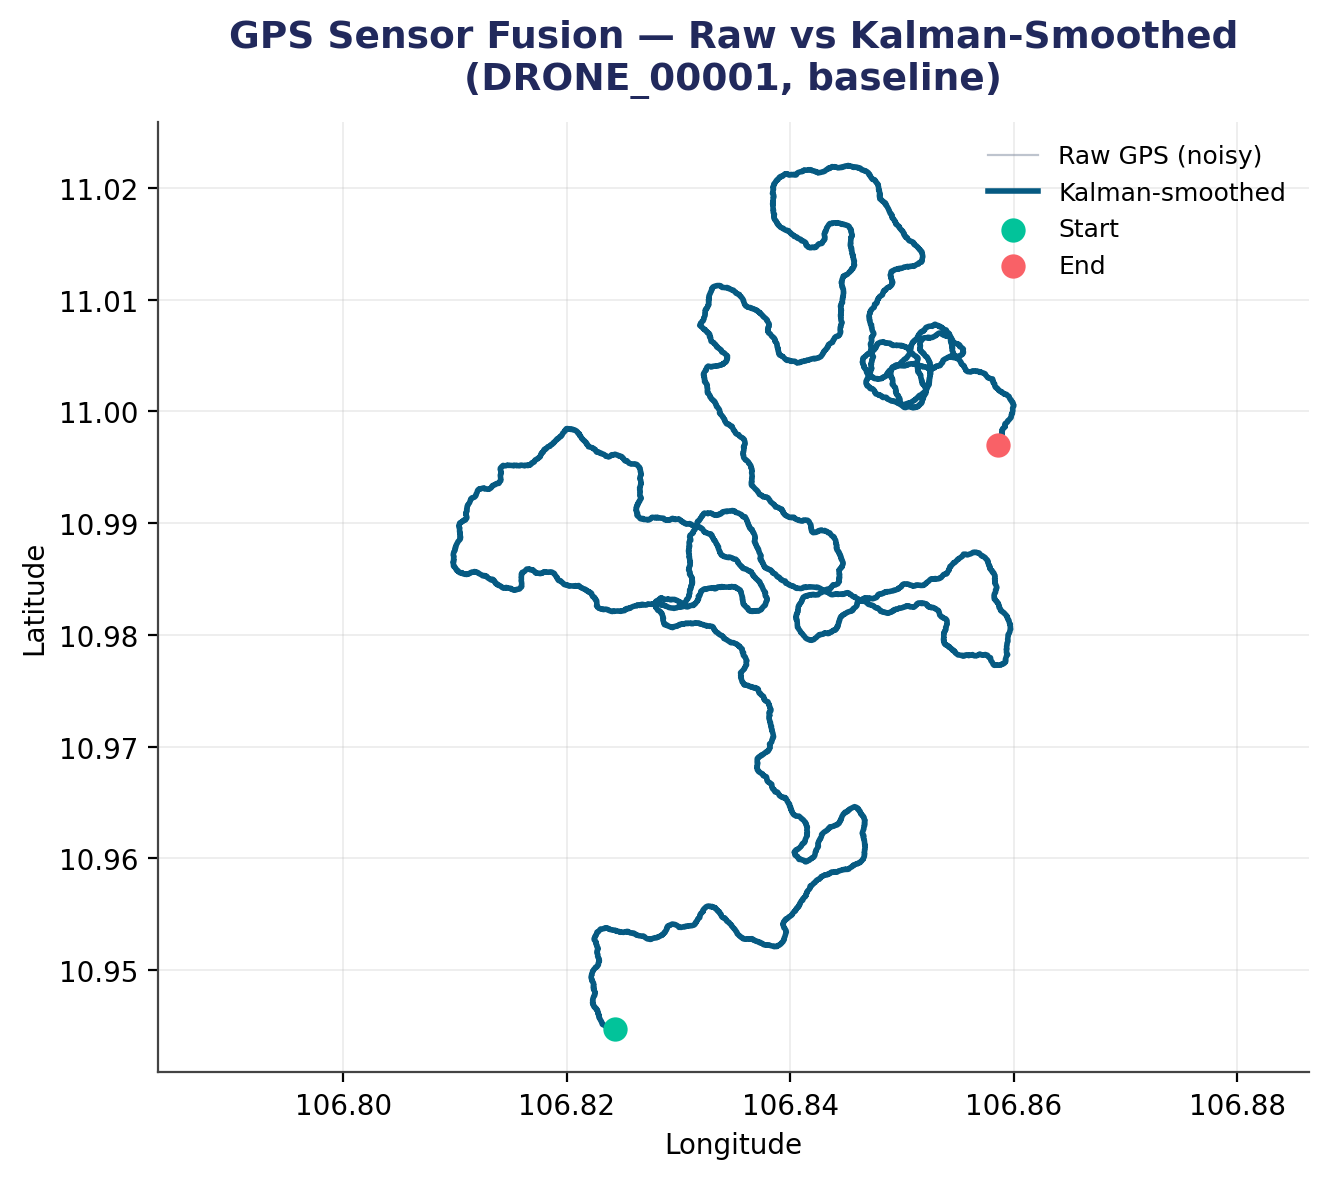

In [ ]:
sys.path.insert(0, os.getcwd())
from kalman_filter import KalmanFilter2D

def smooth_drone(pid):
    grp = telemetry[telemetry["drone_id"] == pid].sort_values("timestamp").reset_index(drop=True)
    kf = KalmanFilter2D()
    lat_s, lon_s = [], []
    for _, r in grp.iterrows():
        la, lo = kf.update(r["gps_lat"], r["gps_lon"])
        lat_s.append(la); lon_s.append(lo)
    grp = grp.copy()
    grp["gps_lat_smooth"] = lat_s
    grp["gps_lon_smooth"] = lon_s
    return grp

pid_main = "DRONE_00001"
grp_main = smooth_drone(pid_main)

fig, ax = plt.subplots(figsize=(6.8, 6), dpi=200)
ax.plot(grp_main["gps_lon"], grp_main["gps_lat"], color=GREY, linewidth=0.8, alpha=0.55, label="Raw GPS (noisy)")
ax.plot(grp_main["gps_lon_smooth"], grp_main["gps_lat_smooth"], color=DEEPBLUE, linewidth=2.0, label="Kalman-smoothed")
ax.scatter([grp_main["gps_lon"].iloc[0]], [grp_main["gps_lat"].iloc[0]], color=MINT, s=60, zorder=5, label="Start")
ax.scatter([grp_main["gps_lon"].iloc[-1]], [grp_main["gps_lat"].iloc[-1]], color=CORAL, s=60, zorder=5, label="End")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"GPS Sensor Fusion — Raw vs Kalman-Smoothed\n({pid_main}, {profile_map[pid_main]})",
             fontsize=13.5, fontweight="bold", color=NAVY, pad=12)
style_ax(ax); ax.legend(fontsize=9, frameon=False); ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
savefig(fig, "08_gps_kalman_path.png")
plt.show()


Saved -> fig\09_gps_noise_reduction.png


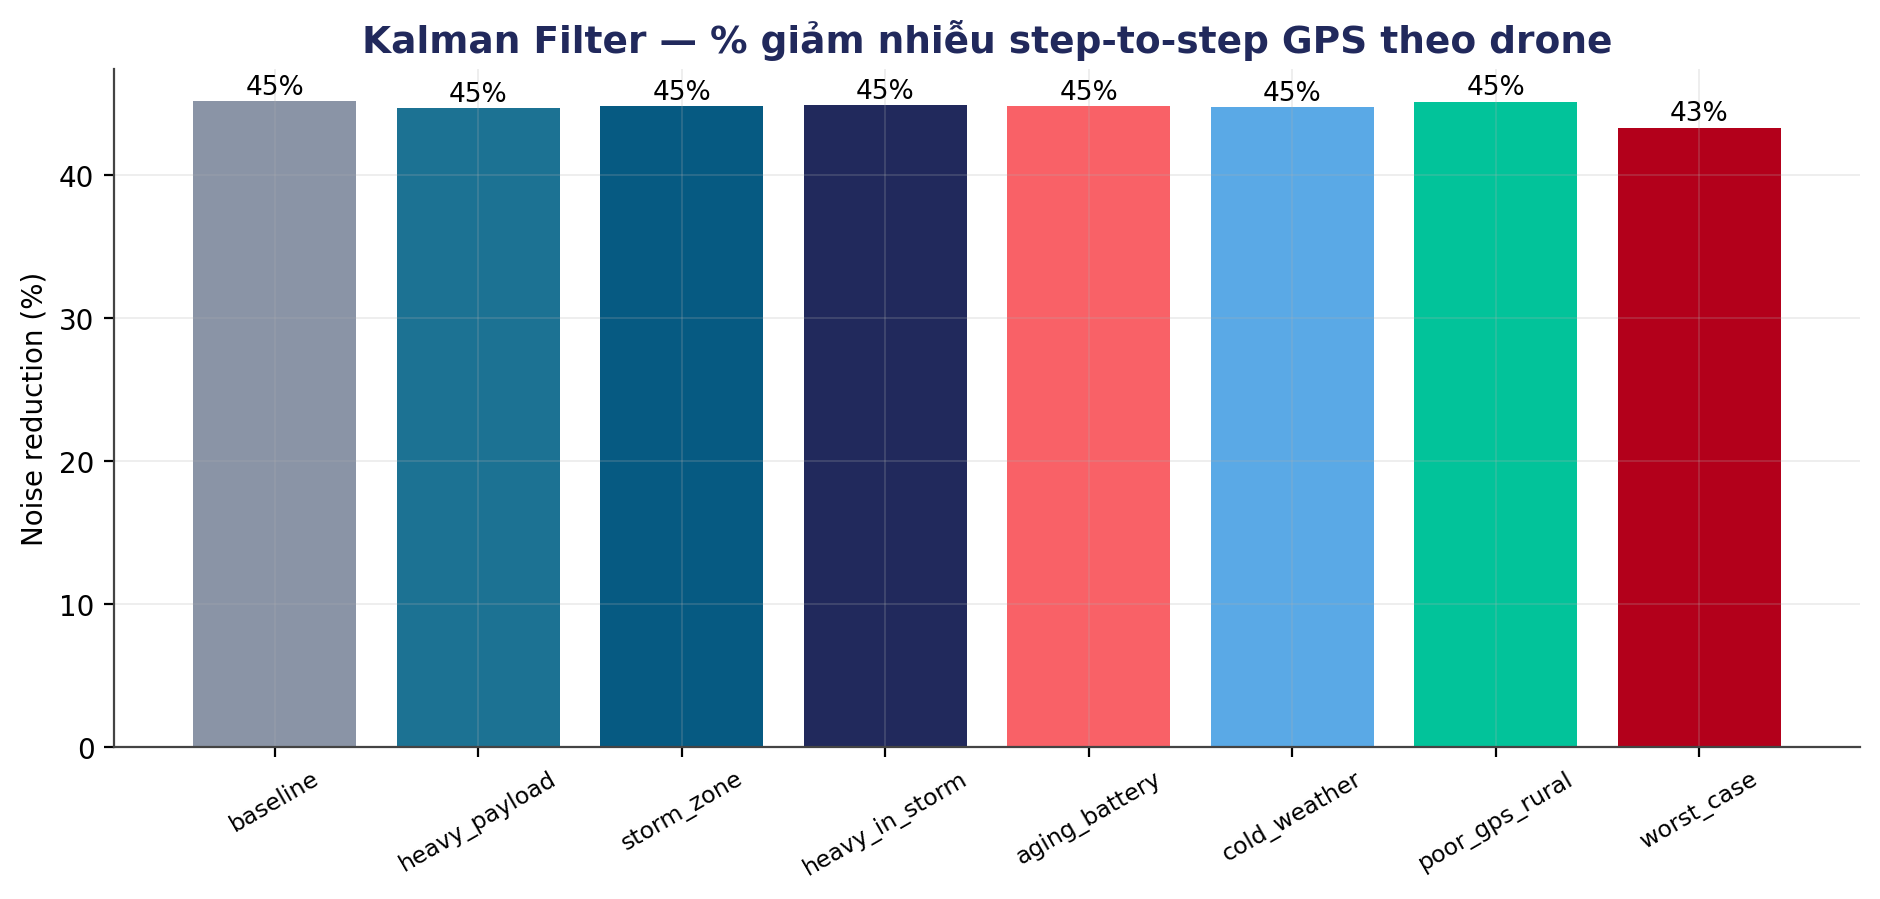

,drone_id,profile,raw_step_std,smooth_step_std,noise_reduction_pct
0,DRONE_00001,baseline,0.000035,0.000019,45.206416
1,DRONE_00002,heavy_payload,0.000034,0.000019,44.725211
2,DRONE_00003,storm_zone,0.000035,0.000019,44.876795
3,DRONE_00004,heavy_in_storm,0.000035,0.000019,44.935864
4,DRONE_00005,aging_battery,0.000034,0.000019,44.825570
5,DRONE_00006,cold_weather,0.000034,0.000019,44.774110
6,DRONE_00007,poor_gps_rural,0.000052,0.000028,45.163159
7,DRONE_00008,worst_case,0.000045,0.000025,43.346973


In [ ]:
# MỚI: định lượng mức độ làm mượt thay vì chỉ nhìn hình -- tính khoảng cách
# (xấp xỉ, đơn vị độ) giữa điểm raw và điểm đã smooth cho TỪNG drone, xem
# Kalman filter cắt giảm nhiễu bao nhiêu %.
def gps_noise_reduction(pid):
    grp = smooth_drone(pid)
    raw_jitter = np.sqrt(grp["gps_lat"].diff()**2 + grp["gps_lon"].diff()**2).dropna()
    smooth_jitter = np.sqrt(grp["gps_lat_smooth"].diff()**2 + grp["gps_lon_smooth"].diff()**2).dropna()
    return raw_jitter.std(), smooth_jitter.std()

rows = []
for pid in sorted(telemetry["drone_id"].unique()):
    raw_std, smooth_std = gps_noise_reduction(pid)
    reduction_pct = 100 * (1 - smooth_std / raw_std)
    rows.append((pid, profile_map[pid], raw_std, smooth_std, reduction_pct))

noise_df = pd.DataFrame(rows, columns=["drone_id", "profile", "raw_step_std", "smooth_step_std", "noise_reduction_pct"])

fig, ax = plt.subplots(figsize=(9.5, 4.6), dpi=200)
colors_nd = [PROFILE_COLORS.get(p, GREY) for p in noise_df["profile"]]
bars = ax.bar(noise_df["profile"], noise_df["noise_reduction_pct"], color=colors_nd)
for b, v in zip(bars, noise_df["noise_reduction_pct"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9.5)
ax.set_title("Kalman Filter — % giảm nhiễu step-to-step GPS theo drone", fontsize=13.5, fontweight="bold", color=NAVY)
ax.set_ylabel("Noise reduction (%)")
ax.tick_params(axis="x", rotation=30, labelsize=8.5)
style_ax(ax)
fig.tight_layout()
savefig(fig, "09_gps_noise_reduction.png")
plt.show()

noise_df


## 7. Fleet Health Heatmap — trạng thái từng drone theo từng cửa sổ 5 phút

Đọc trực tiếp cột `battery_status` mà **M2 đã tính sẵn** trong `fact_gold_summary`
(không tự tính lại) — chỉ trực quan hoá.


Saved -> fig\10_fleet_health_heatmap.png


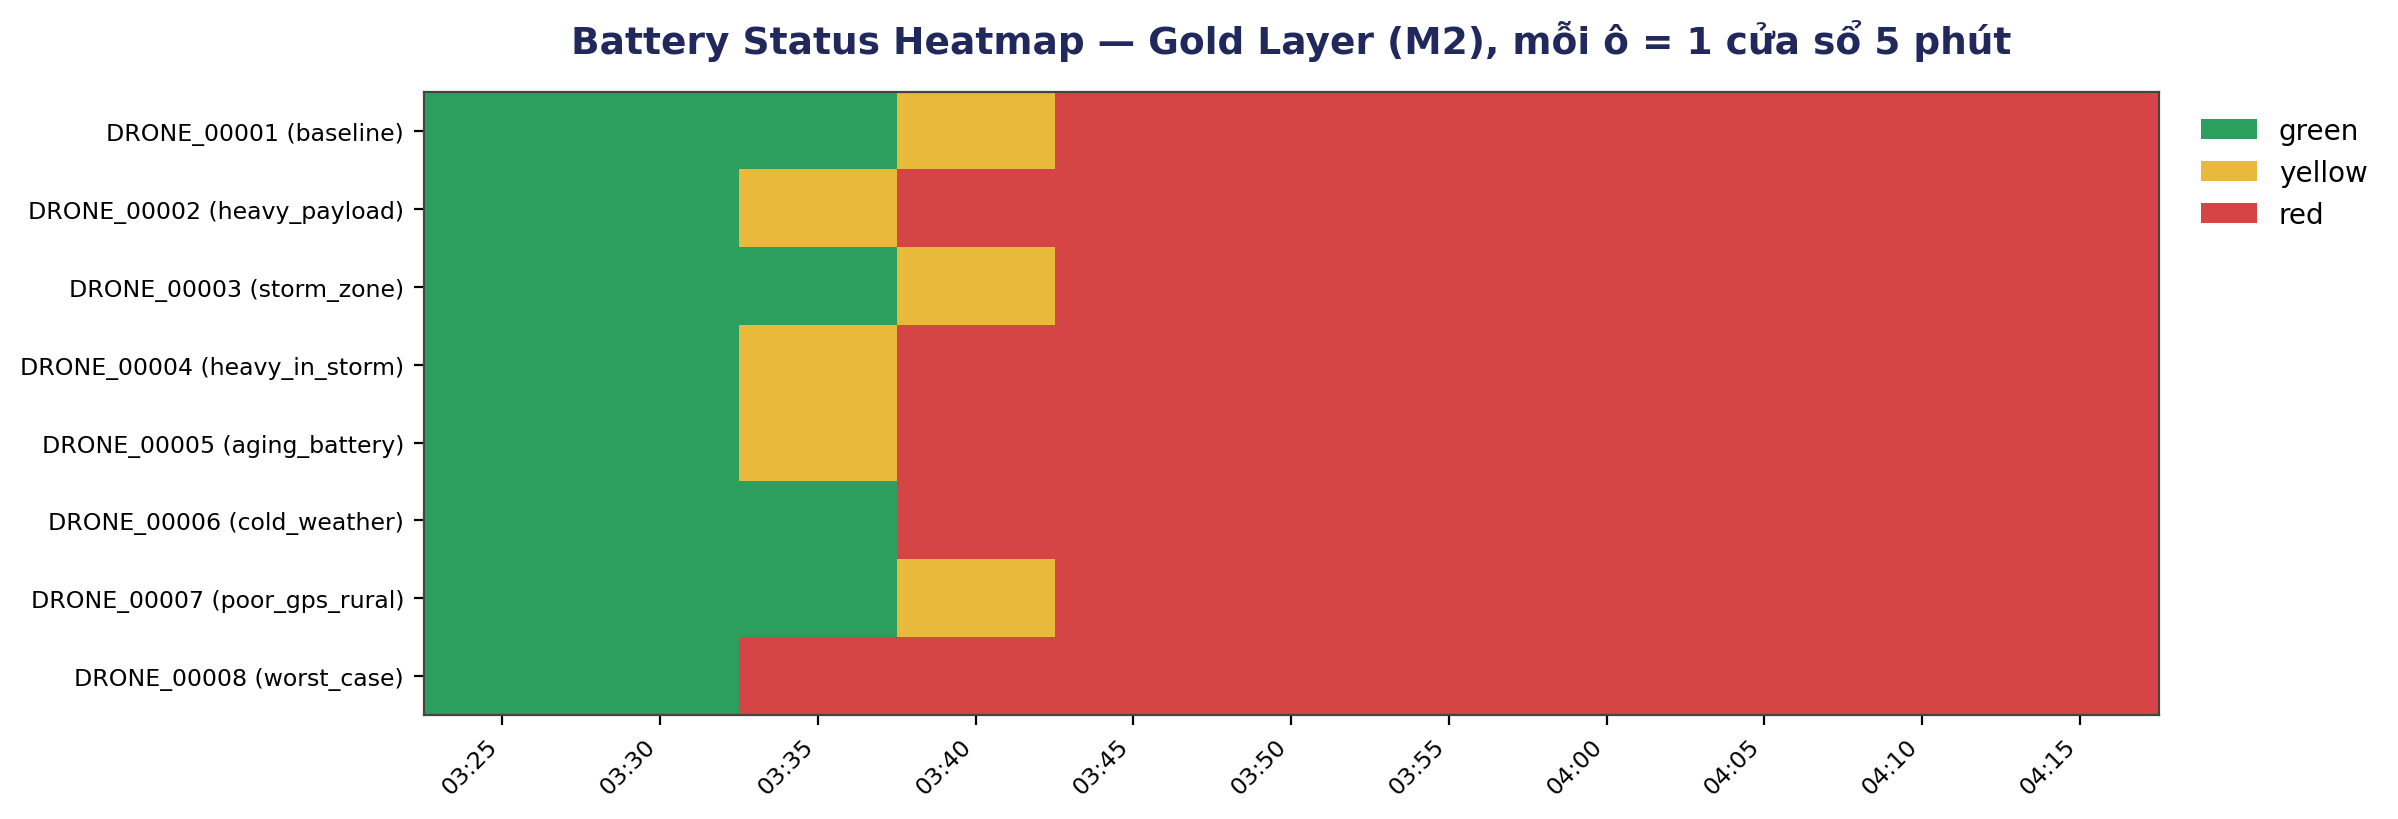

In [ ]:
status_num = {"green": 0, "yellow": 1, "red": 2}
pivot = gold.pivot_table(index="drone_id", columns="window_end", values="battery_status",
                          aggfunc="first")
pivot_num = pivot.map(lambda s: status_num.get(s, np.nan) if pd.notna(s) else np.nan)

from matplotlib.colors import ListedColormap
cmap = ListedColormap([STATUS_COLORS["green"], STATUS_COLORS["yellow"], STATUS_COLORS["red"]])

fig, ax = plt.subplots(figsize=(max(8, 1.1 * pivot_num.shape[1]), 4.2), dpi=200)
im = ax.imshow(pivot_num.values, cmap=cmap, vmin=0, vmax=2, aspect="auto")
ax.set_yticks(range(len(pivot_num.index)))
ax.set_yticklabels([f"{d} ({profile_map[d]})" for d in pivot_num.index], fontsize=8.5)
ax.set_xticks(range(len(pivot_num.columns)))
ax.set_xticklabels([c.strftime("%H:%M") for c in pivot_num.columns], rotation=45, fontsize=8.5, ha="right")
ax.set_title("Battery Status Heatmap — Gold Layer (M2), mỗi ô = 1 cửa sổ 5 phút",
              fontsize=13.5, fontweight="bold", color=NAVY, pad=14)
legend_elems = [Patch(facecolor=STATUS_COLORS[s], label=s) for s in ["green", "yellow", "red"]]
ax.legend(handles=legend_elems, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
fig.tight_layout()
savefig(fig, "10_fleet_health_heatmap.png")
plt.show()


Saved -> fig\11_status_distribution.png


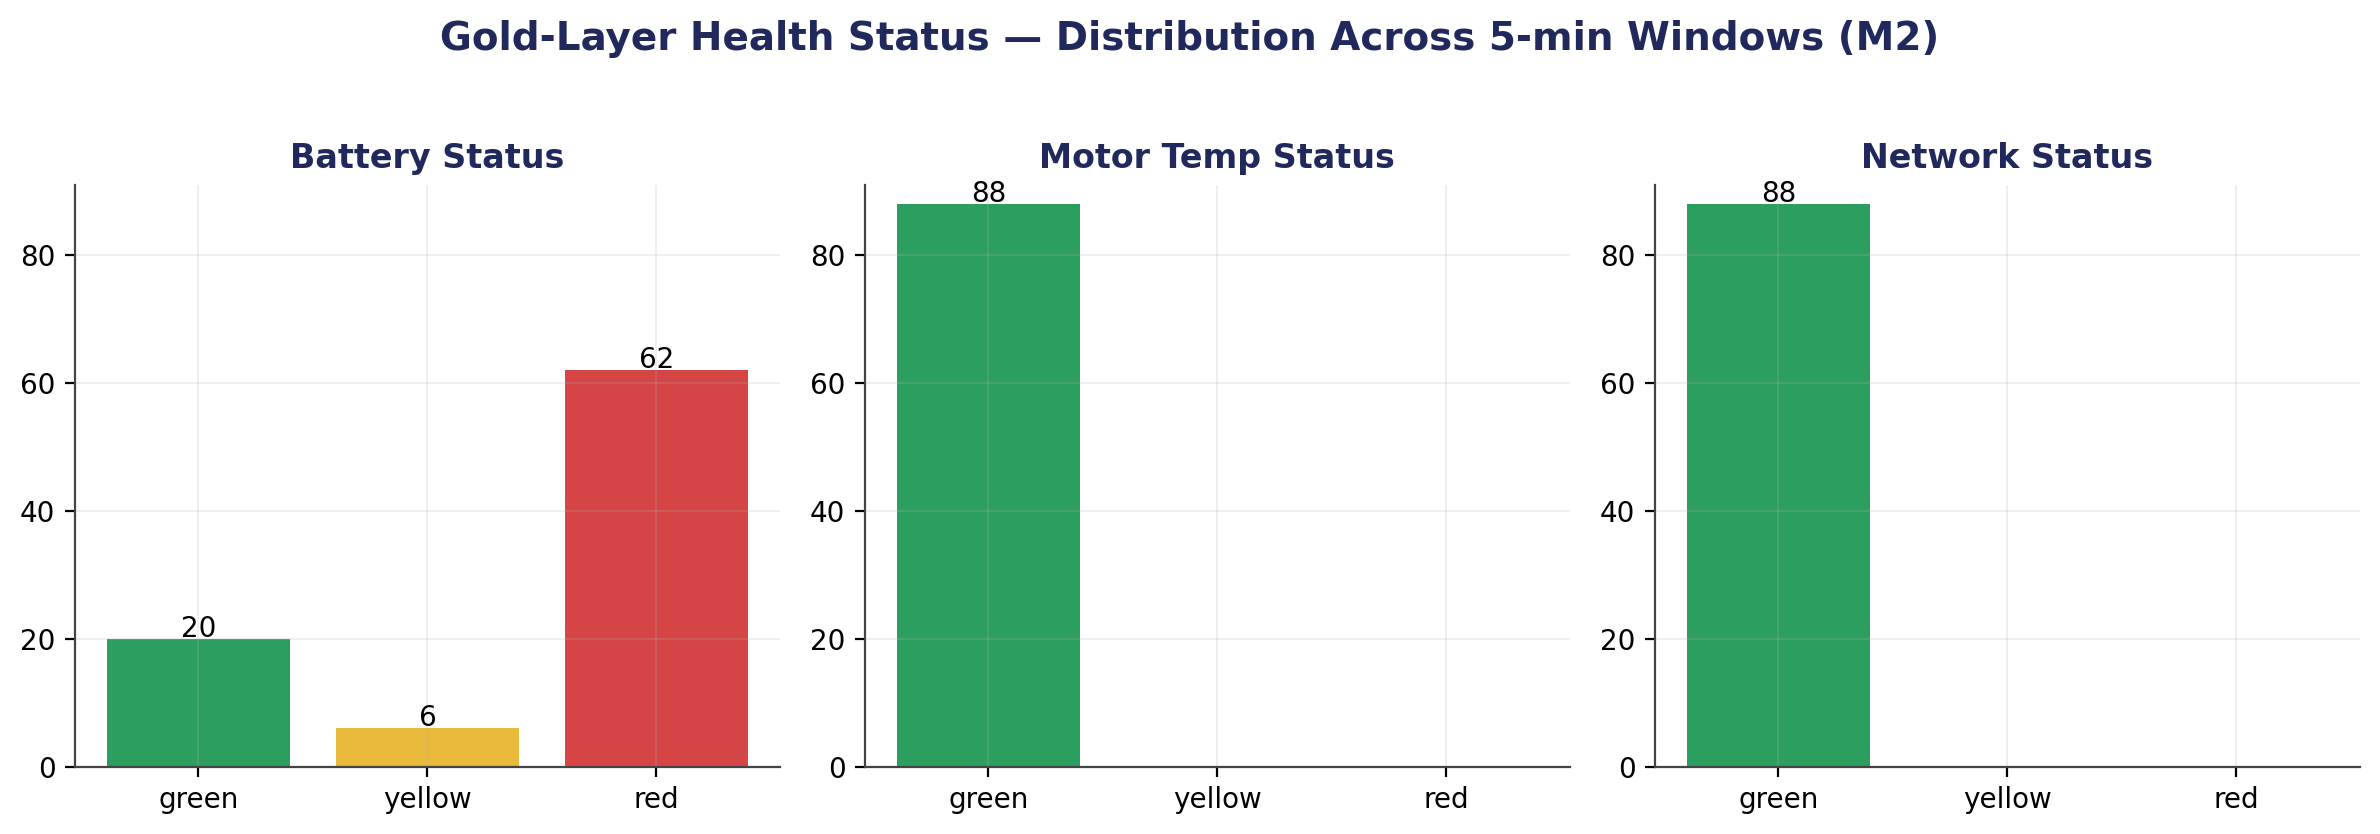

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=200)
for ax, col, title in zip(axes, ["battery_status", "motor_temp_status", "network_status"],
                           ["Battery Status", "Motor Temp Status", "Network Status"]):
    counts = gold[col].value_counts().reindex(["green", "yellow", "red"]).fillna(0)
    bars = ax.bar(counts.index, counts.values, color=[STATUS_COLORS[c] for c in counts.index])
    for b, v in zip(bars, counts.values):
        if v > 0:
            ax.text(b.get_x() + b.get_width()/2, v + 0.3, int(v), ha="center", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold", color=NAVY)
    ax.set_ylim(0, gold.shape[0] + 3)
    style_ax(ax)
fig.suptitle("Gold-Layer Health Status — Distribution Across 5-min Windows (M2)",
             fontsize=14, fontweight="bold", color=NAVY, y=1.03)
fig.tight_layout()
savefig(fig, "11_status_distribution.png")
plt.show()


## 8. M4 — ETR Quantile Regression

Chạy trực tiếp **file `m4_ml_engineer.py` thật** của bạn qua `subprocess`
(không viết lại logic training), rồi đọc lại `fact_gold_summary` sau khi
M4 UPDATE xong 4 cột của nó.


In [ ]:
result = subprocess.run([sys.executable, "m4_ml_engineer.py", "--db", DB_PATH],
                         capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("m4_ml_engineer.py thất bại — xem log ở trên.")

gold2 = pd.read_sql_query("SELECT * FROM fact_gold_summary", conn)
gold2["window_end"] = pd.to_datetime(gold2["window_end"], utc=True)
gold2["profile_label"] = gold2["drone_id"].map(profile_map)
gold2[["drone_id", "window_end", "etr_lower_min", "etr_upper_min", "gps_lat_smooth"]].head()


[INFO] Đã import KalmanFilter2D thật từ kalman_filter.py (M3)
[INFO] Đang đọc fact_telemetry từ drone_fleet.db ...
[INFO] Đọc được 68971 dòng.
[INFO] Đang train Quantile Regression (ETR) ...
[INFO] Train xong Quantile Regression trên 68971 dòng.
[INFO] Đang chạy Kalman smoothing cho GPS ...
[INFO] Đang gộp cửa sổ 5 phút ...
[INFO] Có 88 cửa sổ (drone_id, window_end).
[INFO] fact_gold_summary hiện có 88 dòng do M2 tạo.
[INFO] Đã UPDATE 88 dòng trong fact_gold_summary.



,drone_id,window_end,etr_lower_min,etr_upper_min,gps_lat_smooth
0,DRONE_00001,2026-07-14 03:25:00+00:00,0.0,48.586670,10.953657
1,DRONE_00002,2026-07-14 03:25:00+00:00,0.0,47.427703,10.950532
2,DRONE_00003,2026-07-14 03:25:00+00:00,0.0,48.402030,10.952567
3,DRONE_00004,2026-07-14 03:25:00+00:00,0.0,47.714841,10.949680
4,DRONE_00005,2026-07-14 03:25:00+00:00,0.0,47.926885,10.950783


Saved -> fig\12_etr_predictions.png


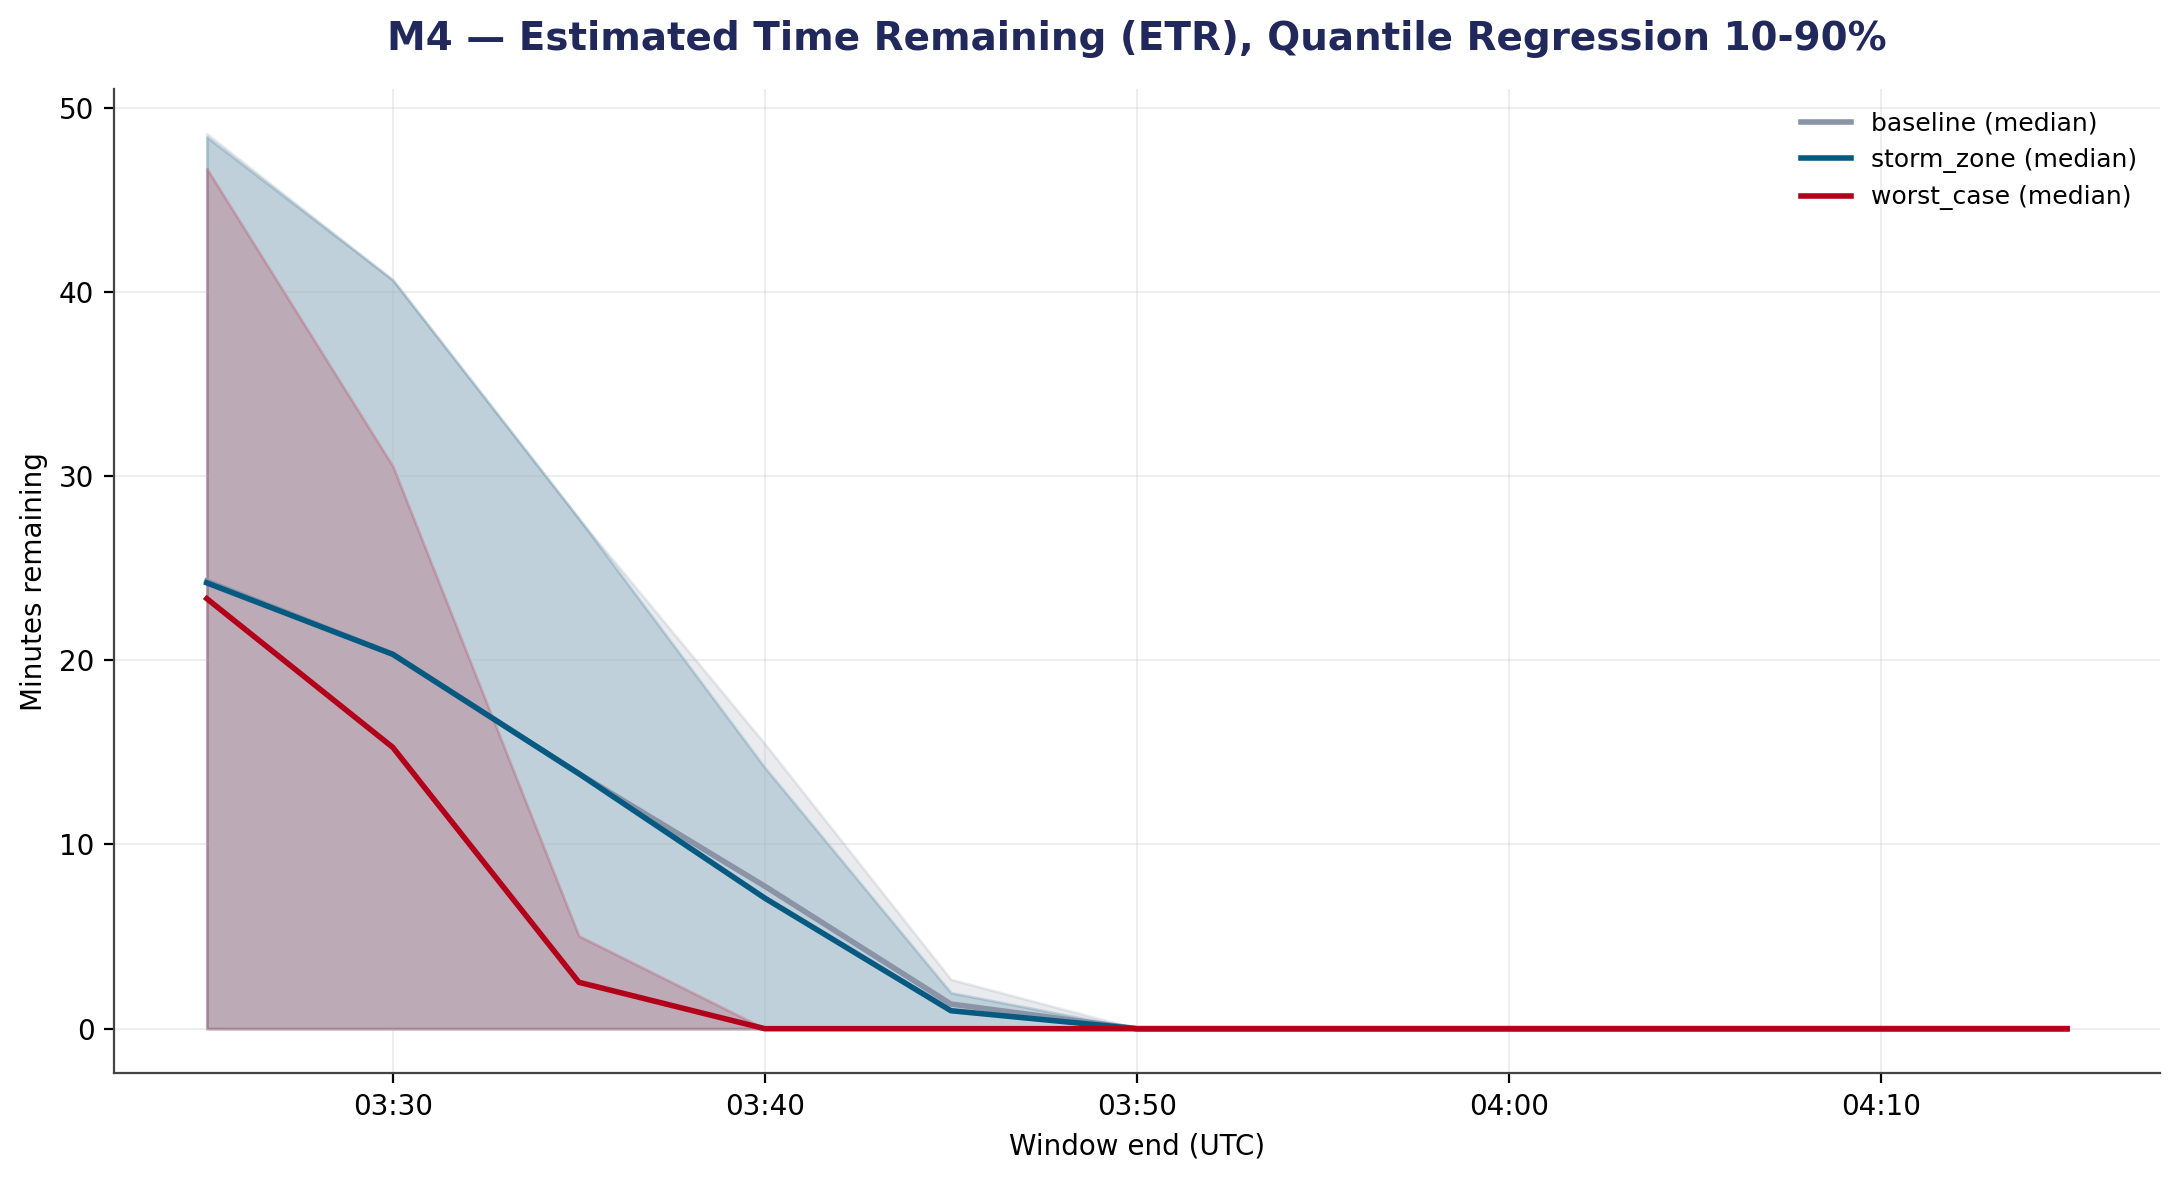

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6), dpi=200)
for label in ["baseline", "storm_zone", "worst_case"]:
    pid = [k for k, v in profile_map.items() if v == label][0]
    grp = gold2[gold2["drone_id"] == pid].sort_values("window_end")
    x = grp["window_end"]
    ax.plot(x, (grp["etr_lower_min"] + grp["etr_upper_min"]) / 2, color=PROFILE_COLORS[label],
            linewidth=2, label=f"{label} (median)")
    ax.fill_between(x, grp["etr_lower_min"], grp["etr_upper_min"], color=PROFILE_COLORS[label], alpha=0.18)
ax.set_title("M4 — Estimated Time Remaining (ETR), Quantile Regression 10-90%",
             fontsize=14, fontweight="bold", color=NAVY, pad=14)
ax.set_ylabel("Minutes remaining"); ax.set_xlabel("Window end (UTC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
style_ax(ax); ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
savefig(fig, "12_etr_predictions.png")
plt.show()


Saved -> fig\13_etr_interval_width_by_profile.png


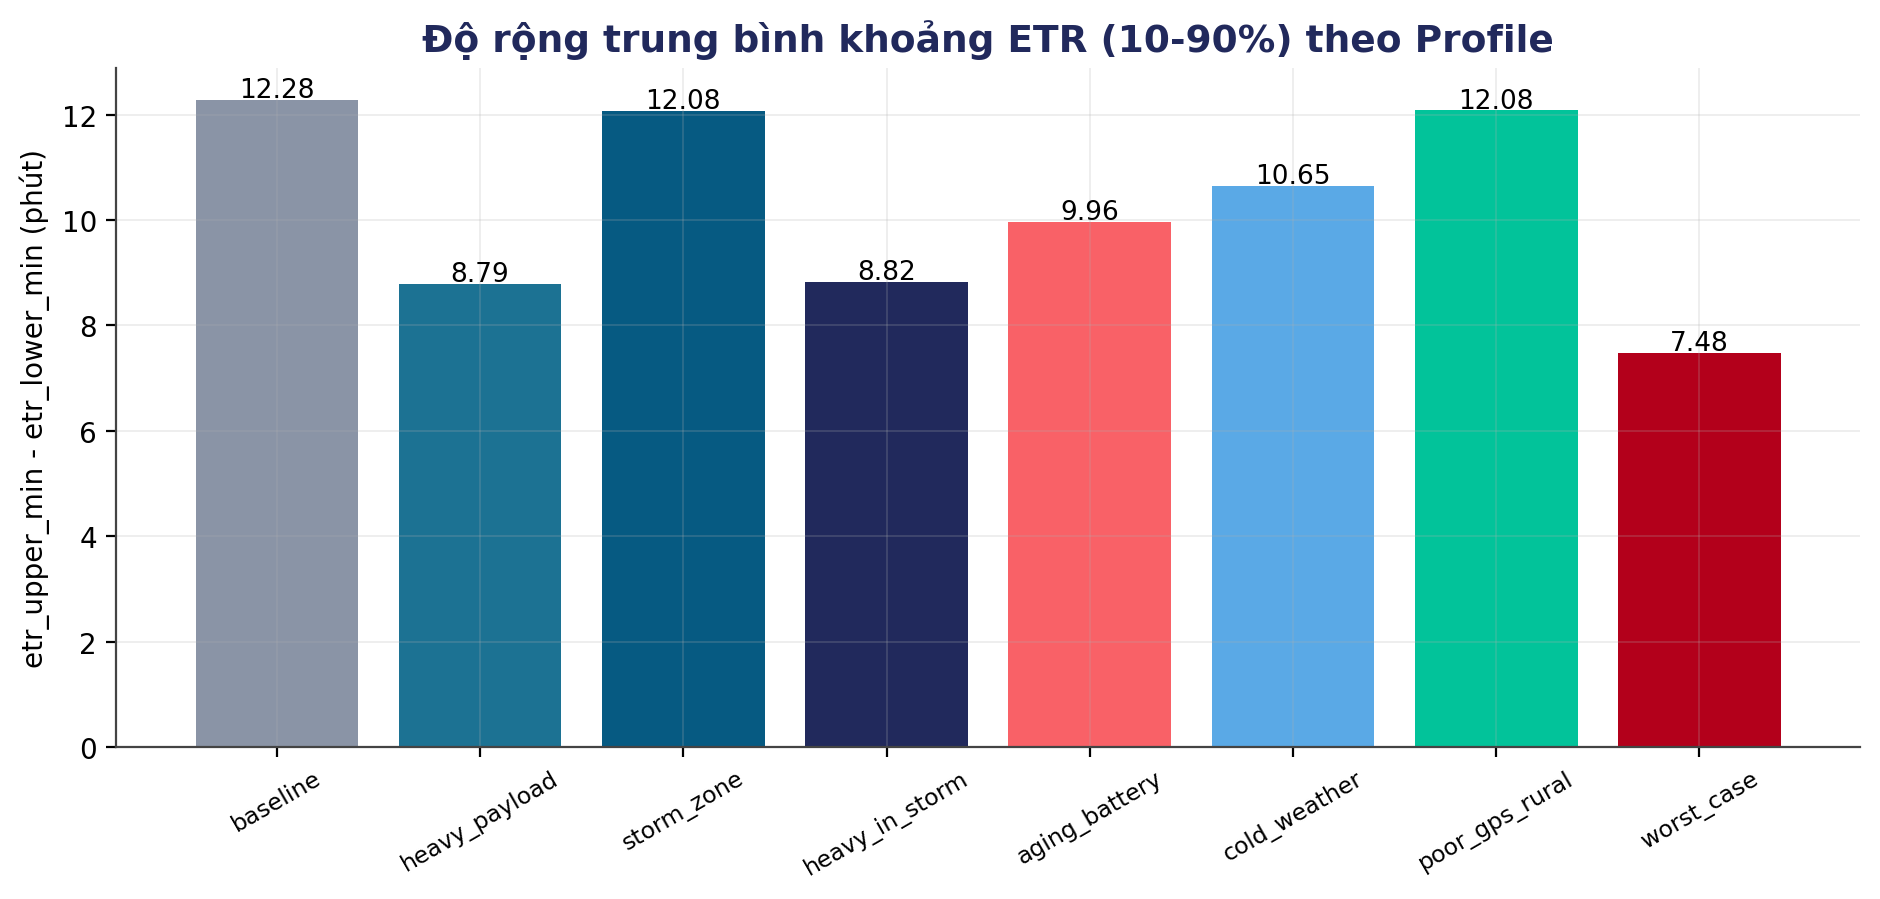

In [ ]:
# MỚI: bề rộng khoảng tin cậy ETR theo profile -- profile nào có bay càng
# bất ổn (storm/heavy/aging) thì model càng KHÔNG chắc chắn (khoảng rộng hơn)?
gold2["etr_width"] = gold2["etr_upper_min"] - gold2["etr_lower_min"]
width_by_profile = gold2.groupby("profile_label")["etr_width"].mean().reindex(
    [p for p in PROFILE_COLORS if p in gold2["profile_label"].unique()]
)

fig, ax = plt.subplots(figsize=(9.5, 4.6), dpi=200)
colors_w = [PROFILE_COLORS.get(p, GREY) for p in width_by_profile.index]
bars = ax.bar(width_by_profile.index, width_by_profile.values, color=colors_w)
for b, v in zip(bars, width_by_profile.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}", ha="center", fontsize=9.5)
ax.set_title("Độ rộng trung bình khoảng ETR (10-90%) theo Profile", fontsize=13.5, fontweight="bold", color=NAVY)
ax.set_ylabel("etr_upper_min - etr_lower_min (phút)")
ax.tick_params(axis="x", rotation=30, labelsize=8.5)
style_ax(ax)
fig.tight_layout()
savefig(fig, "13_etr_interval_width_by_profile.png")
plt.show()


## 9. ⚠️ Model Diagnostic — ETR target hiện tại bị "leakage"

`remaining_flight_time_min` trong `fact_telemetry` được M2 tính bằng
`estimate_remaining_flight_time_min()` trong `m2_analytics_pipeline.py`.
Bản gốc: `battery_level_pct / 2.0` — hàm tuyến tính tuyệt đối của **1 feature**.


Saved -> fig\14_model_diagnostic_leakage.png


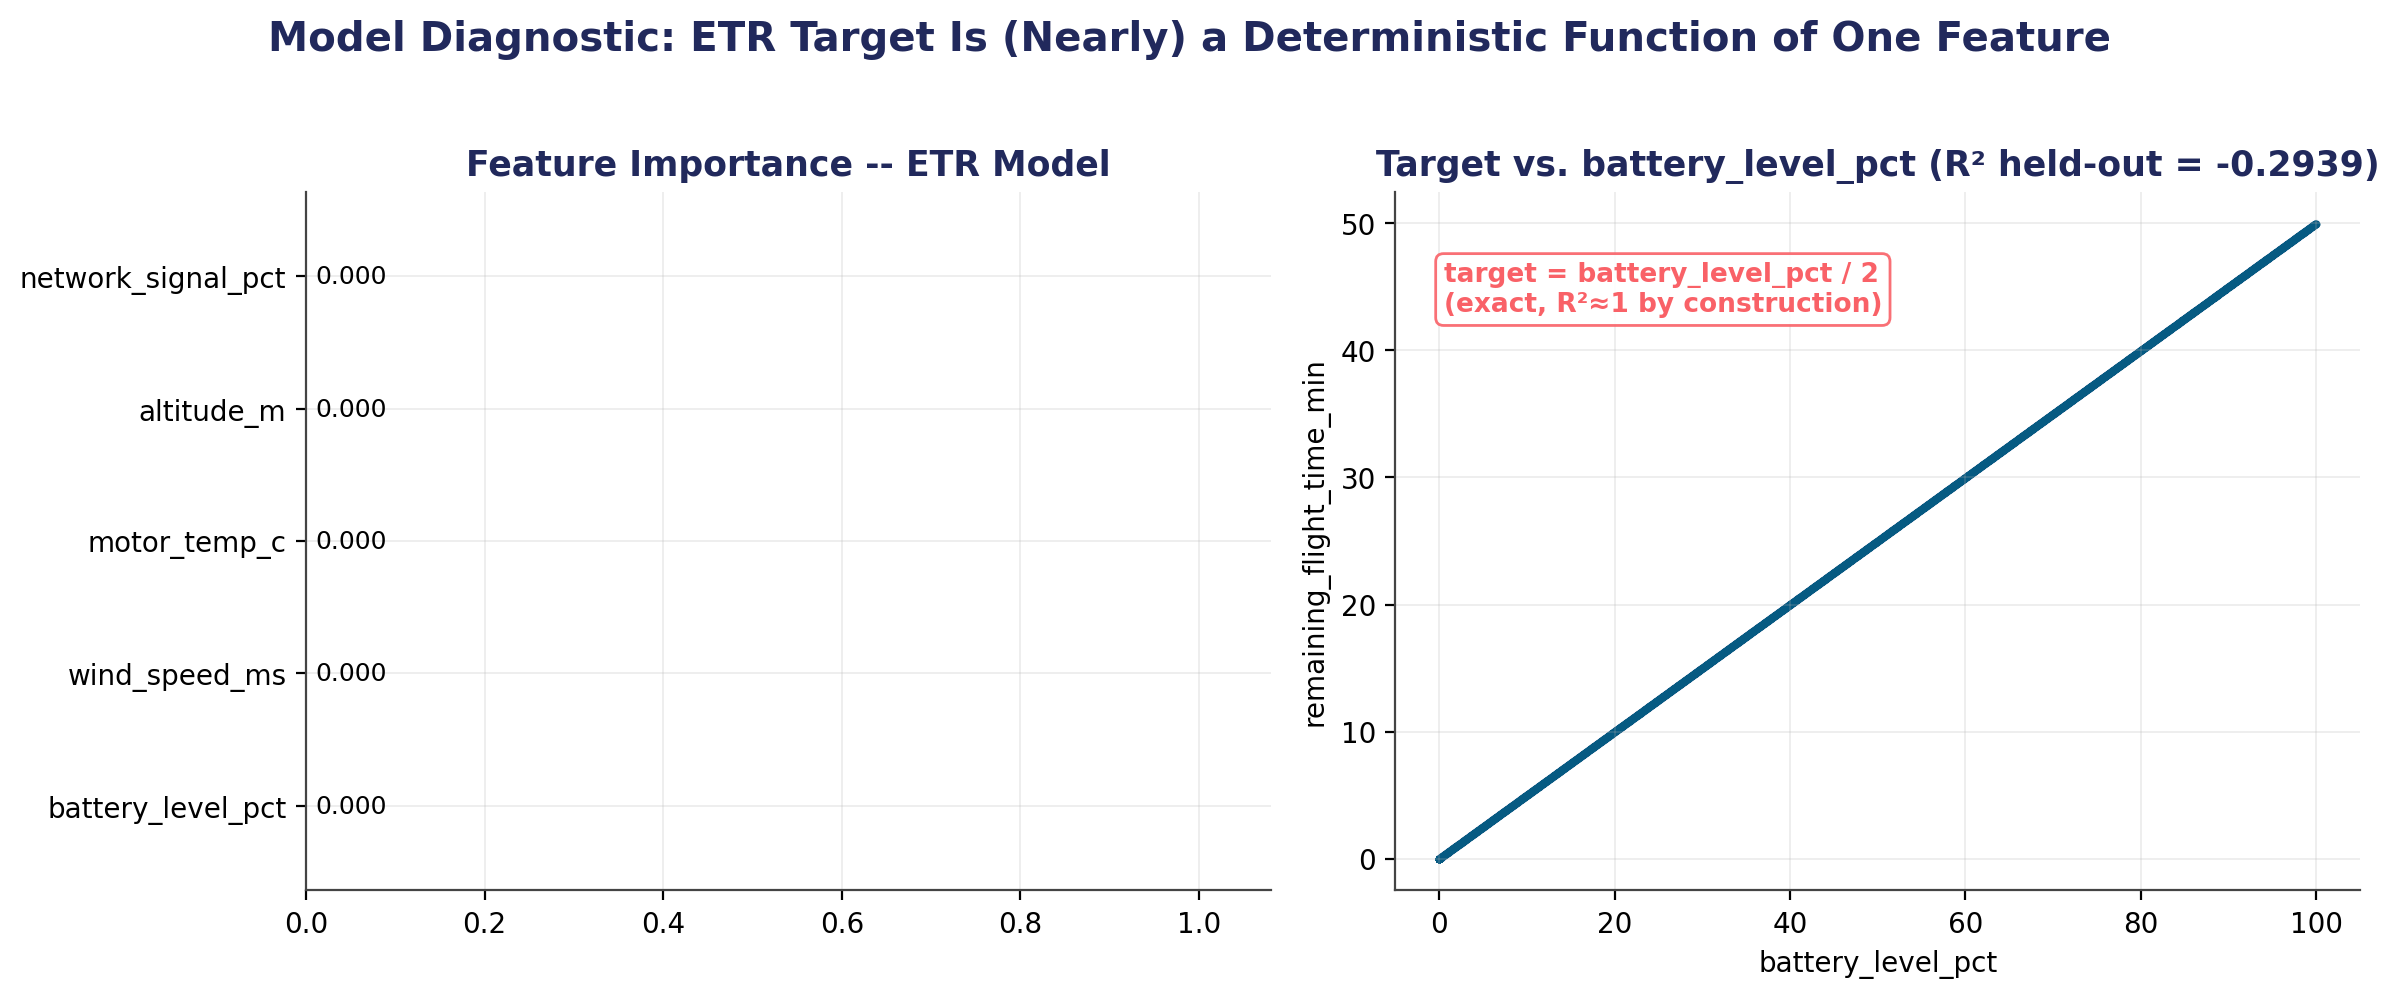

R2: -0.29390710260505215
{'battery_level_pct': np.float64(0.0), 'wind_speed_ms': np.float64(0.0), 'motor_temp_c': np.float64(0.0), 'altitude_m': np.float64(0.0), 'network_signal_pct': np.float64(0.0)}


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

TARGET_COL = "remaining_flight_time_min"
X = telemetry[FEATURE_COLS]
y = telemetry[TARGET_COL]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(loss="quantile", alpha=0.5, n_estimators=200, max_depth=3, random_state=42)
model.fit(Xtr, ytr)
pred = model.predict(Xte)
r2 = r2_score(yte, pred)
importances = model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=200)
order = np.argsort(importances)
axes[0].barh(np.array(FEATURE_COLS)[order], importances[order], color=TEAL)
axes[0].set_title("Feature Importance -- ETR Model", fontsize=12.5, fontweight="bold", color=NAVY)
for i, v in enumerate(importances[order]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
axes[0].set_xlim(0, 1.08); style_ax(axes[0])

axes[1].scatter(telemetry["battery_level_pct"], telemetry[TARGET_COL], s=3, alpha=0.15, color=DEEPBLUE)
axes[1].set_title(f"Target vs. battery_level_pct (R\u00b2 held-out = {r2:.4f})",
                   fontsize=12.5, fontweight="bold", color=NAVY)
axes[1].set_xlabel("battery_level_pct"); axes[1].set_ylabel(TARGET_COL)
style_ax(axes[1])
axes[1].text(0.05, 0.90, "target = battery_level_pct / 2\n(exact, R\u00b2\u22481 by construction)",
             transform=axes[1].transAxes, fontsize=9.5, color=CORAL, fontweight="bold", va="top",
             bbox=dict(boxstyle="round", fc="white", ec=CORAL, alpha=0.9))
fig.suptitle("Model Diagnostic: ETR Target Is (Nearly) a Deterministic Function of One Feature",
             fontsize=14.5, fontweight="bold", color=NAVY, y=1.03)
fig.tight_layout()
savefig(fig, "14_model_diagnostic_leakage.png")
plt.show()

print("R2:", r2)
print(dict(zip(FEATURE_COLS, importances)))


## 10. So sánh target CŨ (placeholder) vs target ĐÃ SỬA (drain-rate thật)

Test lại công thức sửa (đã đưa trong `m2_analytics_pipeline_FIXED.py`) trên
CHÍNH dữ liệu bronze thật -- không giả lập số liệu mới.


Saved -> fig\15_target_before_after_fix.png


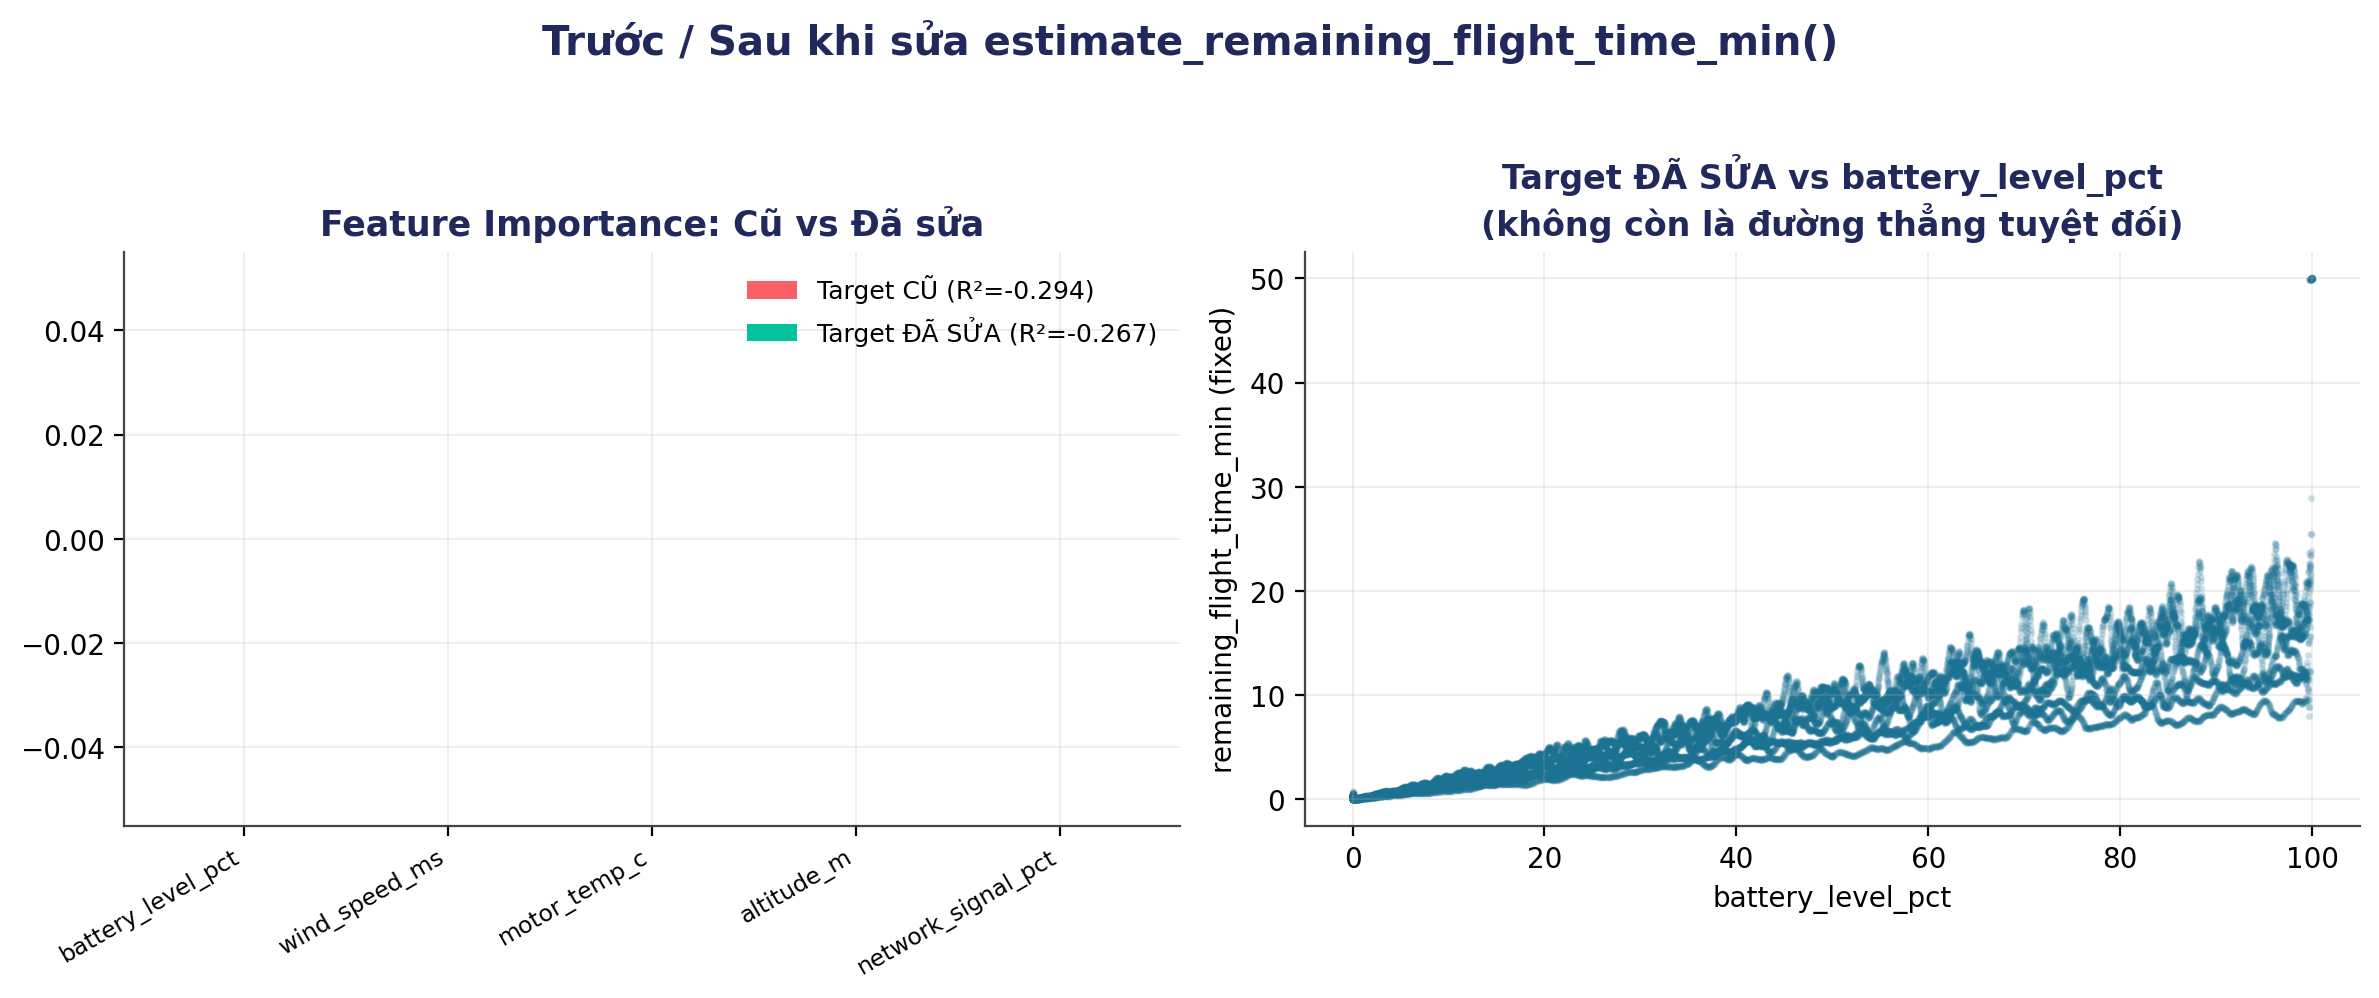

R2 cu: -0.29390710260505215 | R2 da sua: -0.2670522637558066
Importance cu: {'battery_level_pct': np.float64(0.0), 'wind_speed_ms': np.float64(0.0), 'motor_temp_c': np.float64(0.0), 'altitude_m': np.float64(0.0), 'network_signal_pct': np.float64(0.0)}
Importance da sua: {'battery_level_pct': np.float64(0.0), 'wind_speed_ms': np.float64(0.0), 'motor_temp_c': np.float64(0.0), 'altitude_m': np.float64(0.0), 'network_signal_pct': np.float64(0.0)}


In [ ]:
from collections import deque
from datetime import datetime

bronze = pd.read_sql_query("SELECT log_id, raw_json_payload FROM bronze_telemetry ORDER BY log_id", conn)
from schema import TelemetryPayload

_DRAIN_HISTORY_LEN = 30
_MIN_POINTS_FOR_RATE = 5
_FALLBACK_DRAIN_RATE_PCT_PER_MIN = 2.0
_battery_history = {}

def estimate_remaining_flight_time_fixed(payload):
    hist = _battery_history.setdefault(payload.drone_id, deque(maxlen=_DRAIN_HISTORY_LEN))
    ts = datetime.fromisoformat(payload.timestamp.replace("Z", "+00:00"))
    hist.append((ts, payload.battery_level_pct))
    if len(hist) < _MIN_POINTS_FOR_RATE:
        drain_rate = _FALLBACK_DRAIN_RATE_PCT_PER_MIN
    else:
        t0 = hist[0][0]
        xs = [(t - t0).total_seconds() / 60.0 for t, _ in hist]
        ys = [b for _, b in hist]
        n = len(xs)
        mean_x = sum(xs) / n; mean_y = sum(ys) / n
        cov = sum((x - mean_x) * (y - mean_y) for x, y in zip(xs, ys))
        var = sum((x - mean_x) ** 2 for x in xs)
        slope = cov / var if var > 1e-9 else 0.0
        drain_rate = max(-slope, 0.05)
    return round(payload.battery_level_pct / drain_rate, 3)

rows = []
for _, r in bronze.iterrows():
    payload = TelemetryPayload.model_validate_json(r["raw_json_payload"])
    t_new = estimate_remaining_flight_time_fixed(payload)
    rows.append((payload.drone_id, payload.battery_level_pct, payload.wind_speed_ms,
                 payload.motor_temp_c, payload.altitude_m, payload.network_signal_pct, t_new))

fixed_df = pd.DataFrame(rows, columns=["drone_id"] + FEATURE_COLS + ["remaining_flight_time_min_FIXED"])

Xf = fixed_df[FEATURE_COLS]; yf = fixed_df["remaining_flight_time_min_FIXED"]
Xtr2, Xte2, ytr2, yte2 = train_test_split(Xf, yf, test_size=0.2, random_state=42)
model2 = GradientBoostingRegressor(loss="quantile", alpha=0.5, n_estimators=200, max_depth=3, random_state=42)
model2.fit(Xtr2, ytr2)
r2_fixed = r2_score(yte2, model2.predict(Xte2))
imp_fixed = model2.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=200)
x = np.arange(len(FEATURE_COLS)); w = 0.35
axes[0].bar(x - w/2, importances, width=w, label=f"Target CŨ (R\u00b2={r2:.3f})", color=CORAL)
axes[0].bar(x + w/2, imp_fixed, width=w, label=f"Target ĐÃ SỬA (R\u00b2={r2_fixed:.3f})", color=MINT)
axes[0].set_xticks(x); axes[0].set_xticklabels(FEATURE_COLS, rotation=30, ha="right", fontsize=8.5)
axes[0].set_title("Feature Importance: Cũ vs Đã sửa", fontsize=12.5, fontweight="bold", color=NAVY)
axes[0].legend(fontsize=9, frameon=False); style_ax(axes[0])

axes[1].scatter(fixed_df["battery_level_pct"], fixed_df["remaining_flight_time_min_FIXED"],
                s=3, alpha=0.15, color=TEAL)
axes[1].set_title("Target ĐÃ SỬA vs battery_level_pct\n(không còn là đường thẳng tuyệt đối)",
                   fontsize=12, fontweight="bold", color=NAVY)
axes[1].set_xlabel("battery_level_pct"); axes[1].set_ylabel("remaining_flight_time_min (fixed)")
style_ax(axes[1])

fig.suptitle("Trước / Sau khi sửa estimate_remaining_flight_time_min()", fontsize=14.5, fontweight="bold", color=NAVY, y=1.03)
fig.tight_layout()
savefig(fig, "15_target_before_after_fix.png")
plt.show()

print("R2 cu:", r2, "| R2 da sua:", r2_fixed)
print("Importance cu:", dict(zip(FEATURE_COLS, importances)))
print("Importance da sua:", dict(zip(FEATURE_COLS, imp_fixed)))


## 11. Tổng kết — danh sách file đã lưu trong `fig/`

In [ ]:
saved = sorted(os.listdir(FIG_DIR))
for f in saved:
    print(f)
print(f"\nTong cong {len(saved)} hinh da luu trong '{FIG_DIR}/'")
conn.close()


01_pipeline_volume_and_backlog.png
02_hardware_failures_by_drone.png
03_feature_histograms.png
04_feature_boxplots_by_profile.png
05_correlation_heatmap.png
06_battery_drain_profiles.png
07_wind_motor_temp.png
08_gps_kalman_path.png
09_gps_noise_reduction.png
10_fleet_health_heatmap.png
11_status_distribution.png
12_etr_predictions.png
13_etr_interval_width_by_profile.png
14_model_diagnostic_leakage.png
15_target_before_after_fix.png

Tong cong 15 hinh da luu trong 'fig/'
